# Assignment 7 - Plotting File

This notebook contains our code used to analyse the results from our reference sets and create meaningful plots.

## Set-up

The cell below contains the set-up for the analysis. Some of the model inputs are defined, needed libraries and modules are imported and the paths for the results are defined.

In [15]:
# Importing necessary libraries and modules
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import json
import copy
import pathlib
import importlib.util

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.path as _mpath
import geopandas as gpd

# This is a matplotlib deepcopy fix for Path objects, to make the plotting easier
def _fixed_path_deepcopy(self, memo):
    cls = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# In the following code lines we set up the paths to the  root directory that contains the JUSTICE model,
#  the results directory where the reference sets are stored and the plots directory where generated plots are saved
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    NOTEBOOK_DIR = os.path.abspath(".")

JUSTICE_ROOT = os.path.normpath(os.path.join(NOTEBOOK_DIR, "../JUSTICE-main"))
RESULTS_DIR = os.path.normpath(os.path.join(NOTEBOOK_DIR, "results"))
PLOTS_DIR = os.path.join(NOTEBOOK_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

if JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, JUSTICE_ROOT)

os.chdir(JUSTICE_ROOT)

# Importing modules from the JUSTICE model
from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.enumerations import Abatement, DamageFunction, Economy, WelfareFunction
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.model_time import TimeHorizon
from justice.abatement.abatement_enerdata import AbatementEnerdata
from justice.objectives.objective_functions import fraction_of_ensemble_above_threshold
from solvers.emodps.rbf import RBF

# Setting the student configuration path
CONFIG_PATH = os.path.join(NOTEBOOK_DIR, "../config/config_student.json")

# These are the parameters for the reference set generation, they can be changed to generate different reference sets
BACKSTOP_COST = 200
DECLINE_RATE = 0.101
N_ENSEMBLE = 10
THRESHOLD = 2.0

# Here we set the columns of the results that we will be plotting
OBJECTIVE_COLS = [
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

with open(CONFIG_PATH) as fh:
    cfg = json.load(fh)

#Setting up the time horizon and other parameters for the model
time_horizon = TimeHorizon(
    start_year=cfg["start_year"],
    end_year=cfg["end_year"],
    data_timestep=cfg["data_timestep"],
    timestep=cfg["timestep"],
)

years = np.asarray(time_horizon.model_time_horizon).astype(int)
N_TIMESTEPS = len(years)
REGION_LIST = list(DataLoader().REGION_LIST)
N_REGIONS = len(REGION_LIST)
N_INPUTS_RBF = cfg["n_inputs"]
N_RBFS = cfg["n_inputs"] + 2
SCENARIO = cfg["reference_ssp_rcp_scenario_index"]
EC_START_TS = time_horizon.year_to_timestep(
    
    year=cfg["emission_control_start_year"],
    timestep=cfg["timestep"],
)

MAX_TEMP, MIN_TEMP = 16.0, 0.0
MAX_DIFF, MIN_DIFF = 2.0, 0.0

print(f"JUSTICE root: {JUSTICE_ROOT}")
print(f"Results dir : {RESULTS_DIR}")
print(f"Plots dir   : {PLOTS_DIR}")

JUSTICE root: c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\JUSTICE-main
Results dir : c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results
Plots dir   : c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\plots


## Defining reference sets

In [2]:
# Reference sets for the 
ref_temp_two = {
    "Prioritarian 1.5C": os.path.join(RESULTS_DIR, "reference_set_prio_1_5.csv"),
    "Utilitarian 1.5C": os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_bs200_dec0101.csv"),
}

ref_emissions = {
    "Prio 1.5C": os.path.join(RESULTS_DIR, "reference_set_prio_1_5.csv"),
    "Utilitarian 1.5C bs dec": os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_bs200_dec0101.csv"),
    "Prio 2C": os.path.join(RESULTS_DIR, "reference_set_prio_2.csv"),
    "Utilitarian 2C": os.path.join(RESULTS_DIR, "reference_set_utilitarian_2_0_bs550_dec0025.csv"),
    "Utilitarian 1.5C": os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_bs550_dec0025.csv"),
    "Utilitarian 1.5C bs": os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_bs200_dec0025.csv"),

}

ref_ecr_by_set = {
    "Prio 1.5C": os.path.join(RESULTS_DIR, "reference_set_prio_1_5.csv"),
    "Utilitarian 1.5C bs dec": os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_bs200_dec0101.csv"),
    "Prio 2C": os.path.join(RESULTS_DIR, "reference_set_prio_2.csv"),
    "Utilitarian 2C": os.path.join(RESULTS_DIR, "reference_set_utilitarian_2_0_bs550_dec0025.csv"),
    "Utilitarian 1.5C": os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_bs550_dec0025.csv"),
    "Utilitarian 1.5C bs": os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_bs200_dec0025.csv"),

}

util_bs200_path = os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_bs200_dec0101.csv")

## Defining helper functions

In the following code cell we define all the helper functions for the analysis. They all contain a code comment that describes their function, most of them are used to extract data in such a way that it can be plotted easily.

In [ ]:
# The following functions are used to load the reference sets, find the relevant columns, run the policies and extract the results for plotting
def load_reference_set(path):
    """
    Load a reference set CSV file and normalise its column names.

    Parameters
    path : str
        Path to the reference set CSV file.

    Returns
    ref : pandas.DataFrame
        The loaded reference set with whitespace stripped and spaces
        replaced by underscores in the column names.

    Raises
    FileNotFoundError
        If no file exists at the given path.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find: {path}")

    ref = pd.read_csv(path)
    ref.columns = ref.columns.str.strip().str.replace(" ", "_")
    return ref


def find_col(ref, possible_cols):
    """
    Find the first matching column name present in a reference set.

    This function is used to find the relevant column in the reference
    set, it checks for multiple possible column names to ensure
    compatibility with different reference sets. In principle all
    reference sets should have the same column names, but this is a
    safety check.

    Parameters
    ref : pandas.DataFrame
        The reference set to search for columns in.
    possible_cols : list of str
        Candidate column names to check, in order of preference.

    Returns
    col : str
        The first column name from `possible_cols` found in `ref`.

    Raises
    KeyError
        If none of the candidate column names are present in `ref`.
    """
    for col in possible_cols:
        if col in ref.columns:
            return col
    raise KeyError(
        "None of these columns found:\n"
        + ", ".join(possible_cols)
        + "\nAvailable columns are:\n"
        + ", ".join(ref.columns)
    )


def find_threshold_col(ref):
    """
    Find the column containing the threshold exceedance information.

    Parameters
    ref : pandas.DataFrame
        The reference set to search.

    Returns
    col : str
        The name of the threshold exceedance column found in `ref`.
    """
    return find_col(ref, [
        "fraction_above_threshold",
        "fraction_above_1p5C",
        "fraction_above_2C",
        "fraction_of_ensemble_above_threshold",
    ])


def get_anchor_indices(ref):
    """
    Find the indices of the policies that optimise each objective.

    The minimum score is used for the welfare and threshold exceedance
    objectives, while the maximum score is used for the damage and
    abatement objectives, as the welfare loss is calculated as the
    amount of welfare lost, resulting in a wanted minimum, and the
    damage and abatement objectives are calculated as the negative of
    the welfare, resulting in a wanted maximum.

    Parameters
    ref : pandas.DataFrame
        The reference set containing the objective columns.

    Returns
    anchors : dict of str to int
        Mapping from a descriptive anchor label to the row index in
        `ref` of the policy that optimises that objective.
    """
    return {
        "Lowest welfare loss": ref["welfare"].idxmin(),
        "Lowest threshold exceedance": ref["fraction_above_threshold"].idxmin(),
        "Best damage objective": ref["welfare_loss_damage"].idxmax(),
        "Best abatement objective": ref["welfare_loss_abatement"].idxmax(),
    }


def find_gbr_index():
    """
    Find the index of the GBR/UK region in the REGION_LIST.

    Returns
    i : int
        The index of the GBR/UK region within `REGION_LIST`.

    Raises
    ValueError
        If no matching region name is found in `REGION_LIST`.
    """
    region_lower = [str(r).lower() for r in REGION_LIST]
    for cand in ["gbr", "uk", "united kingdom", "britain"]:
        for i, region in enumerate(region_lower):
            if cand in region:
                return i

    print(REGION_LIST)
    raise ValueError("Could not find GBR/UK region in REGION_LIST.")


def mean_global_temperature(datasets):
    """
    Calculate the mean global temperature across ensemble members.

    Parameters
    datasets : dict
        Model output dictionary containing the key "global_temperature".

    Returns
    temp : numpy.ndarray
        The global temperature, averaged over the ensemble axis if the
        input array is two-dimensional.
    """
    temp = np.asarray(datasets["global_temperature"])
    return np.nanmean(temp, axis=1) if temp.ndim == 2 else temp


def global_emissions(datasets):
    """
    Calculate the global emissions, summed across regions.

    Parameters
    datasets : dict
        Model output dictionary containing the key "emissions".

    Returns
    emissions : numpy.ndarray
        Total global emissions over time, averaged across ensemble
        members (if present) and summed across regions.
    """
    emissions = np.asarray(datasets["emissions"])
    if emissions.ndim == 3:
        emissions = np.nanmean(emissions, axis=2)
    return emissions.sum(axis=0)


def mean_global_ecr(ecr):
    """
    Calculate the mean global emission control rate.

    Parameters
    ecr : array_like
        Emission control rate array, optionally including an ensemble
        axis.

    Returns
    ecr_mean : numpy.ndarray
        The emission control rate averaged across ensemble members
        (if present) and across regions.
    """
    ecr = np.asarray(ecr)
    if ecr.ndim == 3:
        ecr = np.nanmean(ecr, axis=2)
    return np.nanmean(ecr, axis=0)


def global_welfare(datasets):
    """
    Extract the temporally disaggregated global welfare.

    Parameters
    datasets : dict
        Model output dictionary containing the key
        "temporally_disaggregated_welfare".

    Returns
    welfare : numpy.ndarray
        The temporally disaggregated welfare values.
    """
    return np.asarray(datasets["temporally_disaggregated_welfare"])


def global_avg_consumption_per_capita(datasets):
    """
    Calculate the global average consumption per capita.

    Parameters
    datasets : dict
        Model output dictionary containing the key
        "consumption_per_capita", expected to be 3-dimensional
        (regions x time x ensemble).

    Returns
    cpc_mean : numpy.ndarray
        Consumption per capita averaged over the region and ensemble
        axes, leaving the time axis.

    Raises
    ValueError
        If "consumption_per_capita" is not 3-dimensional.
    """
    cpc = np.asarray(datasets["consumption_per_capita"])
    if cpc.ndim != 3:
        raise ValueError(f"Unexpected consumption_per_capita shape: {cpc.shape}")
    return np.nanmean(cpc, axis=(0, 2))


def gbr_consumption_per_capita(datasets):
    """
    Calculate the UK (GBR) average consumption per capita.

    Parameters
    datasets : dict
        Model output dictionary containing the key
        "consumption_per_capita", expected to be 3-dimensional
        (regions x time x ensemble).

    Returns
    cpc_gbr : numpy.ndarray
        Consumption per capita for the GBR region, averaged over the
        ensemble axis, leaving the time axis.

    Raises
    ValueError
        If "consumption_per_capita" is not 3-dimensional.
    """
    gbr_idx = find_gbr_index()
    cpc = np.asarray(datasets["consumption_per_capita"])
    if cpc.ndim != 3:
        raise ValueError(f"Unexpected consumption_per_capita shape: {cpc.shape}")
    return np.nanmean(cpc[gbr_idx, :, :], axis=1)


def run_policy_with_backstop(
    policy_row,
    backstop_cost=BACKSTOP_COST,
    backstop_cost_decline_rate_per_5_year=DECLINE_RATE,
    welfare_function_type=WelfareFunction.UTILITARIAN.value[0],
    n_ensemble=N_ENSEMBLE,
    threshold=THRESHOLD,
):
    """
    Run the JUSTICE model for a given policy under specific backstop settings.

    This function runs the policy defined by the given row of the
    reference set, with specific backstop settings and welfare
    function, and returns results.

    Parameters
    policy_row : pandas.Series
        A row from a reference set containing the RBF decision
        variables (centers, radii, weights) that define the policy.
    backstop_cost : float, optional
        The backstop cost used in the abatement module (default is
        `BACKSTOP_COST`).
    backstop_cost_decline_rate_per_5_year : float, optional
        The decline rate of the backstop cost per 5-year period
        (default is `DECLINE_RATE`).
    welfare_function_type : int, optional
        The welfare function type to use in the model (default is
        `WelfareFunction.UTILITARIAN.value[0]`).
    n_ensemble : int, optional
        The number of climate ensemble members to use (default is
        `N_ENSEMBLE`).
    threshold : float, optional
        The temperature threshold used to compute the fraction of the
        ensemble above it (default is `THRESHOLD`).

    Returns
    result : dict
        Dictionary containing:

        - "ecr" : numpy.ndarray
            The constrained emission control rate, averaged across
            ensemble members.
        - "datasets" : dict
            The full model output dictionary from `model.evaluate()`.
        - "fraction_above_threshold" : float
            The fraction of the climate ensemble exceeding `threshold`
            at the configured year of interest.
    """
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()

    centers = np.array([policy_row[f"center_{i}"] for i in range(c_shape[0])])
    radii = np.array([policy_row[f"radii_{i}"] for i in range(r_shape[0])])
    weights = np.array([policy_row[f"weights_{i}"] for i in range(w_shape[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )
    #Modelling choice of (10) ensemble members that as linearly spaced
    ensemble_indices = list(np.linspace(1, 1000, n_ensemble, dtype=int))

    JUSTICE.hard_reset()

    model = JUSTICE(
        scenario=SCENARIO,
        climate_ensembles=ensemble_indices,
        economy_type=Economy.NEOCLASSICAL, #standard economy model
        damage_function_type=DamageFunction.KALKUHL, #standard damage
        abatement_type=Abatement.ENERDATA,
        social_welfare_function_type=welfare_function_type,
    )

    model.abatement = AbatementEnerdata(
        input_dataset=model.data_loader,
        time_horizon=model.time_horizon,
        scenario=model.scenario,
        backstop_cost=backstop_cost, #here the policy of the backstop is set in the abatement module
        backstop_cost_decline_rate_per_5_year=backstop_cost_decline_rate_per_5_year, #same goes for the decline rate
    )

    no_ens = model.no_of_ensembles
    ecr = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)

    prev_temp = np.zeros(no_ens)
    diff = np.zeros(no_ens)

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :],
            t,
            allow_fallback=False,
        )

        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )

        data_t = model.stepwise_evaluate(timestep=t)
        temp = data_t["global_temperature"][t, :]

        if t % 5 == 0:
            diff = temp - prev_temp
            prev_temp = temp

        scaled_temp = (temp - MIN_TEMP) / (MAX_TEMP - MIN_TEMP)
        scaled_diff = (diff - MIN_DIFF) / (MAX_DIFF - MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    datasets = model.evaluate()

    temp_year_idx = time_horizon.year_to_timestep(
        year=cfg["temperature_year_of_interest"],
        timestep=cfg["timestep"],
    )

    frac_above = fraction_of_ensemble_above_threshold(
        temperature=datasets["global_temperature"],
        temperature_year_index=temp_year_idx,
        threshold=float(threshold),
    )

    return {
        "ecr": np.nanmean(constrained_ecr, axis=2),
        "datasets": datasets,
        "fraction_above_threshold": float(frac_above),
    }


#here reference sets are defined to extract relevant backstop settings and welfare function
BS200_DEC0101_REFERENCE_SETS = {
    "reference_set_utilitarian_1_5_bs200_dec0101.csv",
}
BS200_DEC0025_REFERENCE_SETS = {
    "reference_set_utilitarian_1_5_bs200_dec0025.csv",
}
PRIORITARIAN_REFERENCE_SETS = {
    "reference_set_prio_1_5.csv",
}


def get_welfare_function_type(path):
    """
    Determine the welfare function type associated with a reference set.

    Parameters
    path : str
        Path to the reference set CSV file.

    Returns
    welfare_function_type : int
        `WelfareFunction.PRIORITARIAN.value[0]` (inequality aversion = 2)
        if the file belongs to `PRIORITARIAN_REFERENCE_SETS`, otherwise
        `WelfareFunction.UTILITARIAN.value[0]` (inequality aversion = 0).
    """
    filename = os.path.basename(path)

    if filename in PRIORITARIAN_REFERENCE_SETS:
        return WelfareFunction.PRIORITARIAN.value[0]  # inequality aversion = 2

    return WelfareFunction.UTILITARIAN.value[0]       # inequality aversion = 0


def get_backstop_settings(path):
    """
    Determine the backstop cost settings associated with a reference set.

    Parameters
    path : str
        Path to the reference set CSV file.

    Returns
    settings : dict
        Dictionary with keys:

        - "backstop_cost" : float
        - "backstop_cost_decline_rate_per_5_year" : float

        The values depend on which reference set group `path` belongs
        to, defaulting to backstop_cost=550 and
        backstop_cost_decline_rate_per_5_year=0.025 if no match is
        found.
    """
    filename = os.path.basename(path)

    if filename in BS200_DEC0101_REFERENCE_SETS:
        return {
            "backstop_cost": 200,
            "backstop_cost_decline_rate_per_5_year": 0.101,
        }

    if filename in BS200_DEC0025_REFERENCE_SETS:
        return {
            "backstop_cost": 200,
            "backstop_cost_decline_rate_per_5_year": 0.025,
        }

    return {
        "backstop_cost": 550,
        "backstop_cost_decline_rate_per_5_year": 0.025,
    }


def run_lowest_threshold_policy(path):
    """
    Run the policy with the lowest threshold exceedance from a reference set.

    This policy is used as the anchor policy throughout the analysis.

    Parameters
    path : str
        Path to the reference set CSV file.

    Returns
    result : dict
        The model output dictionary returned by
        `run_policy_with_backstop`.
    row : pandas.Series
        The reference set row corresponding to the selected policy.
    """
    ref = load_reference_set(path)
    idx = ref[find_threshold_col(ref)].idxmin()
    settings = get_backstop_settings(path)
    welfare_function_type = get_welfare_function_type(path)

    return run_policy_with_backstop(
        ref.loc[idx],
        welfare_function_type=welfare_function_type,
        **settings,
    ), ref.loc[idx]


def run_four_policies(path):
    """
    Run the optimal policies for all four objectives in a reference set.

    Parameters
    path : str
        Path to the reference set CSV file.

    Returns
    results : dict of str to dict
        Mapping from each anchor label (as returned by
        `get_anchor_indices`) to the corresponding model output
        dictionary returned by `run_policy_with_backstop`.
    """
    ref = load_reference_set(path)
    results = {}
    settings = get_backstop_settings(path)
    welfare_function_type = get_welfare_function_type(path)

    for label, idx in get_anchor_indices(ref).items():
        print(
            f"Running {os.path.basename(path)} | {label} "
            f"| backstop={settings['backstop_cost']} "
            f"| decline={settings['backstop_cost_decline_rate_per_5_year']} "
            f"| welfare_function={welfare_function_type}"
        )

        results[label] = run_policy_with_backstop(
            ref.loc[idx],
            welfare_function_type=welfare_function_type,
            **settings,
        )

    return results


## Running the policies

According to the mandate, the UK draws a red line on the 1.5 degrees threshold. To do so, policy candidates were filtered based on the objective that is most important to the UK. Therefore, the policy that respects this red line the best is selected, rather than evaluating all generated policies per reference set, isolating the rulesets that minimize temperature overshoots. The objective that reflects this red line the best, is the fraction above threshold. Therefore, the anchor policy, the policy optimises the (has the smallest value for) fraction above threshold is found for each reference set. To be able to later compare the other policies, the anchor policies of all four objectives are also found for our most promosing run (utilitarian, threshold = 1.5, backstop = 200 and decline rate = 0.101).

In [23]:
# Here we run the lowest-threshold policy for each reference set and store the results in a dictionary

for label, path in ref_emissions.items():
    print(f"Running lowest-threshold policy: {label}")
    result, row = run_lowest_threshold_policy(path)
    lowest_threshold_results[label] = result
    print(row[OBJECTIVE_COLS])
    print("rerun fraction above threshold:", result["fraction_above_threshold"])

util_four = run_four_policies(util_bs200_path)

lowest_threshold_emissions_results = {}

for label, path in ref_emissions.items():
    print(f"Running lowest-threshold emissions policy: {label}")
    result, _ = run_lowest_threshold_policy(path)
    lowest_threshold_emissions_results[label] = result

ecr_by_refset_results = {}

# Here we run the optimal policies for all four objectives for each reference set and store the results in a dictionary
for label, path in ref_ecr_by_set.items():
    ecr_by_refset_results[label] = run_four_policies(path)

Running lowest-threshold policy: Prio 1.5C
welfare                       103.874431
fraction_above_threshold        0.700000
welfare_loss_damage          3976.365971
welfare_loss_abatement      10780.574252
Name: 0, dtype: float64
rerun fraction above threshold: 0.3
Running lowest-threshold policy: Utilitarian 1.5C bs dec
welfare                       103.687674
fraction_above_threshold        0.900000
welfare_loss_damage          3653.837463
welfare_loss_abatement      10955.181206
Name: 1, dtype: float64
rerun fraction above threshold: 0.2
Running lowest-threshold policy: Prio 2C
welfare                       100.991939
fraction_above_threshold        0.200000
welfare_loss_damage          3952.001897
welfare_loss_abatement      10868.264168
Name: 0, dtype: float64
rerun fraction above threshold: 0.3
Running lowest-threshold policy: Utilitarian 2C
welfare                       103.653909
fraction_above_threshold        0.200000
welfare_loss_damage          3650.942782
welfare_loss_aba

## Starting point: Plotting the Global Temperature under the preferred policy

After identifying the anchor policy per reference set, it is important to see how it performs on the most important metric: the global temperature.

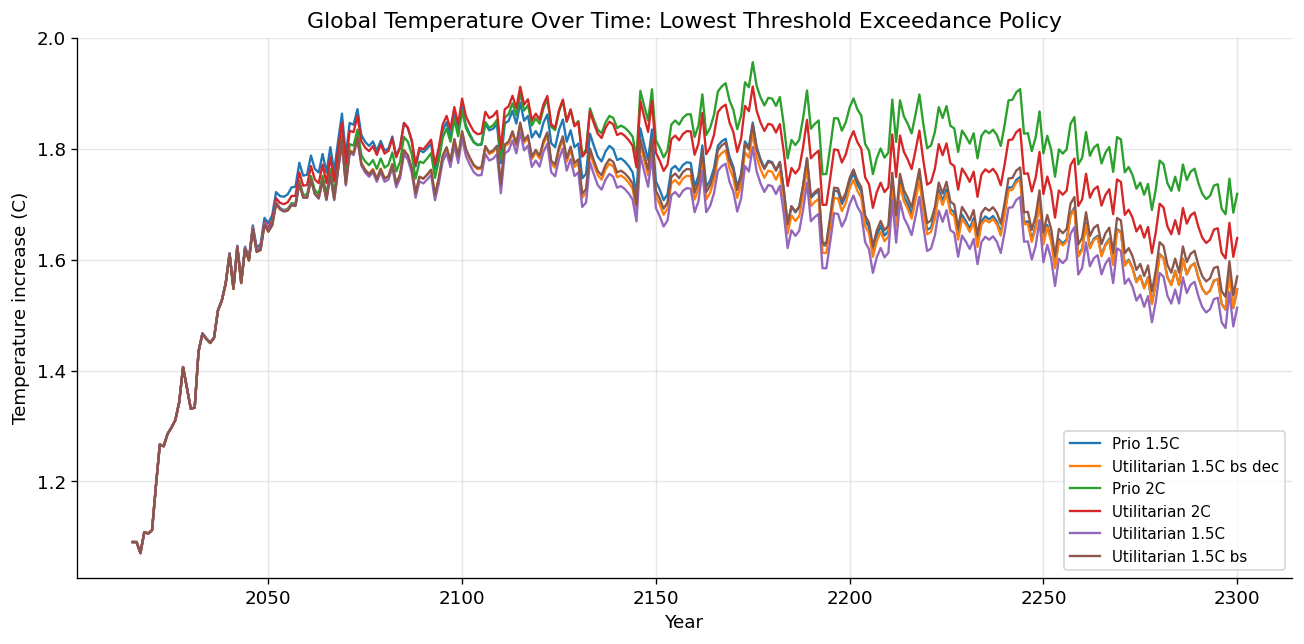

In [ ]:
#Plot 1, global temperature for lowest threshold
fig, ax = plt.subplots(figsize=(11, 5.5))

for label, result in lowest_threshold_results.items():
    ax.plot(years, mean_global_temperature(result["datasets"]), linewidth=1.4, label=label)

ax.set_title("Global Temperature Over Time: Lowest Threshold Exceedance Policy")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature increase (C)")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)


plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "global_temperature_lowest_threshold_two_refsets.png"), dpi=150)
plt.show()

General findings:
* In all model runs the temperature increase ramps up quickly until 2060, then the curve starts to flatten until ~2110. After 2110 the temperature starts to decline for the 1.5 degrees threshold runs, the 2 degrees runs follow this pattern more slowly. 
* The temperature stays the same across all model runs until about 2050, only here they start to diverge.
* The temperature has a very rough curve across all runs. It is non-smooth and shows the same shocky pattern for each of the runs, this could be due to the natural temperature development of the earth caused by climate and Milankovitch cycles (https://science.nasa.gov/science-research/earth-science/milankovitch-orbital-cycles-and-their-role-in-earths-climate/ and https://www.sciencedirect.com/topics/earth-and-planetary-sciences/climate-cycle).

Run-specific findings:
* The 2 degrees threshold runs perform worst. This is expected as the model is less ambitious in these configurations. Even though they are less ambitious, they both easily stay below the threshold which shows that the 2 degrees target is manageable if the priority is to aim for the lowest temperature. On the contrary, all of the 1.5 threshold runs fail to stay below their threshold. This shows that the 1.5 degrees target is very difficult to achieve under a middle-of-the-road climate scenario.
* While they might not meet the 1.5 degrees threshold, they all end up in the 1.5-1.6 degrees range at year 2300.
* Combining the steep curve and the end state, we can say that even 1.5 degrees runs are nowhere near able to reach the threshold in the near future. However, in the long run, given that serious climate mitigation efforts are made, it is possible to approach and maybe even reach the 1.5 degrees threshold.
* Within the 1.5 degrees threshold utilitarian runs there is some variation. A few interesting things: the 1.5 degrees utilitarian run without backstop changes performs best. The 1.5 utilitarian runs with lower initial backstop costs perform slightly worse than the run without backstop changes, with the run with a higher decline rate performing better than the one without. It is expected that the lower backstop in combination with the higher decline rate outperforms just the lowered backstop as technology that rapidly becomes cheaper means the impact can be increased with the same amount of money/effort. However, it is counterintuitive that these are in turn outperformed by the regular 1.5 degrees utilitarian run, as green technology/offsetting emissions would be more expensive in this configuration.
* The prioritarian runs show interesting patterns. On the one hand, the prioritarian 2 degrees run performs better than the utilitarian 2 degrees at the start, but this switches at ~2125, and at year 2300 the gap is quite large. On the other hand, the prioritarian 1.5 degrees run performs worst at the start and slowly improves to at the end even out with the utilitarian 1.5 with the lowered backstop and increase decline rate. These contrasting patterns are something to investigate.
* The utilitarian welfare lens runs generally perform better than the prioritarian. Among the 2 degrees runs the prioritarian has a slight advantage at the start, but the end result is almost a 0.1 degree advantage for the utilitarian, which is pretty significant. For the 1.5 degree runs, the end states are pretty similar, but all utilitarian runs outperform the prioritarian run at the start.

## Second priority: Welfare aspect

The UK's second priority is maintaining a healthy economy, this can be examined through the scores on the objective welfare loss.

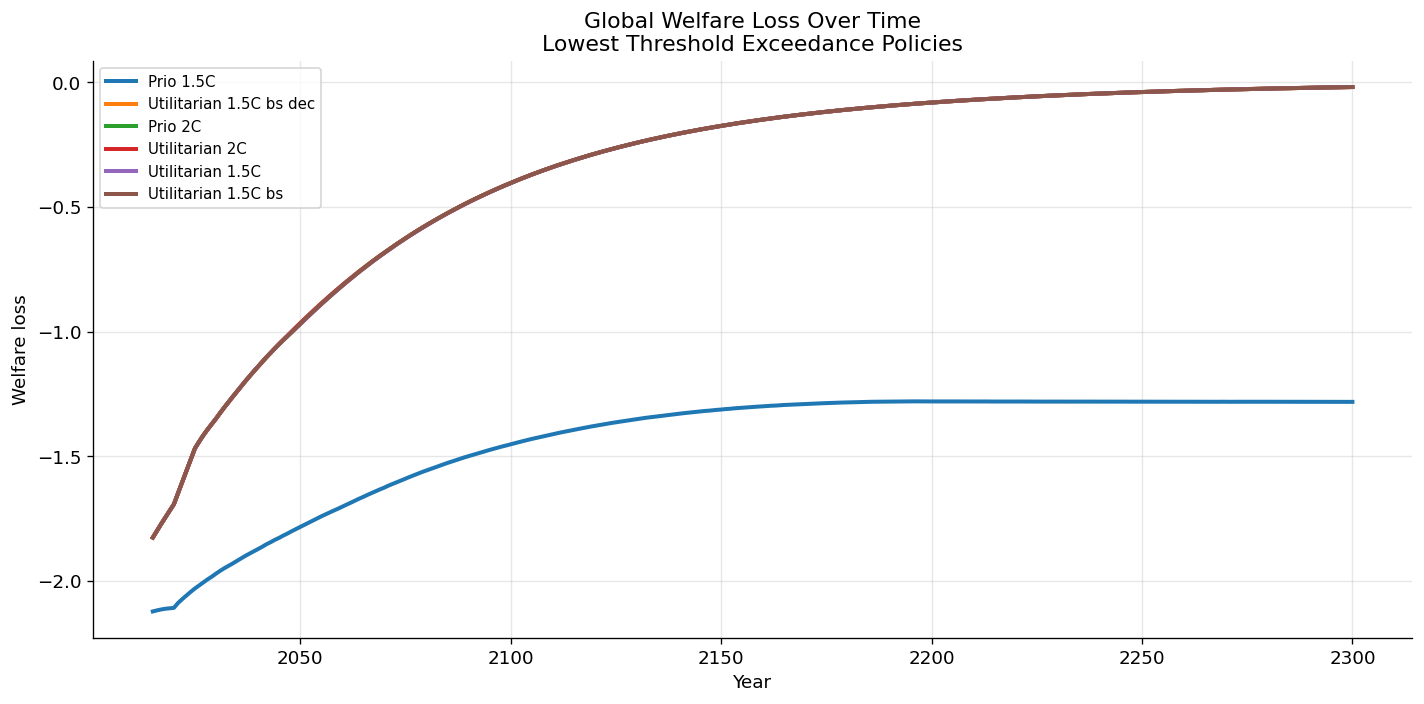

In [ ]:
#Plot 2, welfare loss for lowest threshold
def mean_welfare_loss(datasets):
    welfare = np.asarray(datasets["temporally_disaggregated_welfare"])

    if welfare.ndim == 2:
        # time x ensemble
        return np.nanmean(welfare, axis=1)

    if welfare.ndim == 1:
        return welfare

    raise ValueError(f"Unexpected welfare shape: {welfare.shape}")


fig, ax = plt.subplots(figsize=(12, 6))

for label, result in lowest_threshold_emissions_results.items():
    ax.plot(
        years,
        mean_welfare_loss(result["datasets"]),
        linewidth=2.4,
        label=label,
    )

ax.set_title("Global Welfare Loss Over Time\nLowest Threshold Exceedance Policies")
ax.set_xlabel("Year")
ax.set_ylabel("Welfare loss")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, "welfare_loss_lowest_threshold_ref_emissions.png"),
    dpi=150,
)
plt.show()

Findings:
* The negative values represent loss, so the closer to 0, the better.
* There are no welfare loss differences within the welfare lenses, the line graphs of the utilitarian runs all overlap, the same goes for the prioritarian runs. This requires additional research.
* The Utilitarian lens starkly outperforms the prioritarian lens. At the start, the difference is not that big, even though they both improve the lines do diverge and the difference in welfare loss becomes bigger.
* The utilitarian lens approaches the 0 mark at the end of the runtime.

# Impact lowest threshold exceedance policy on global emissions

Now that we have seen the impact on the temperature and the welfare loss, we wanted to investigate what the lowest threshold exceedance policy means for the global emissions under the different run configurations.

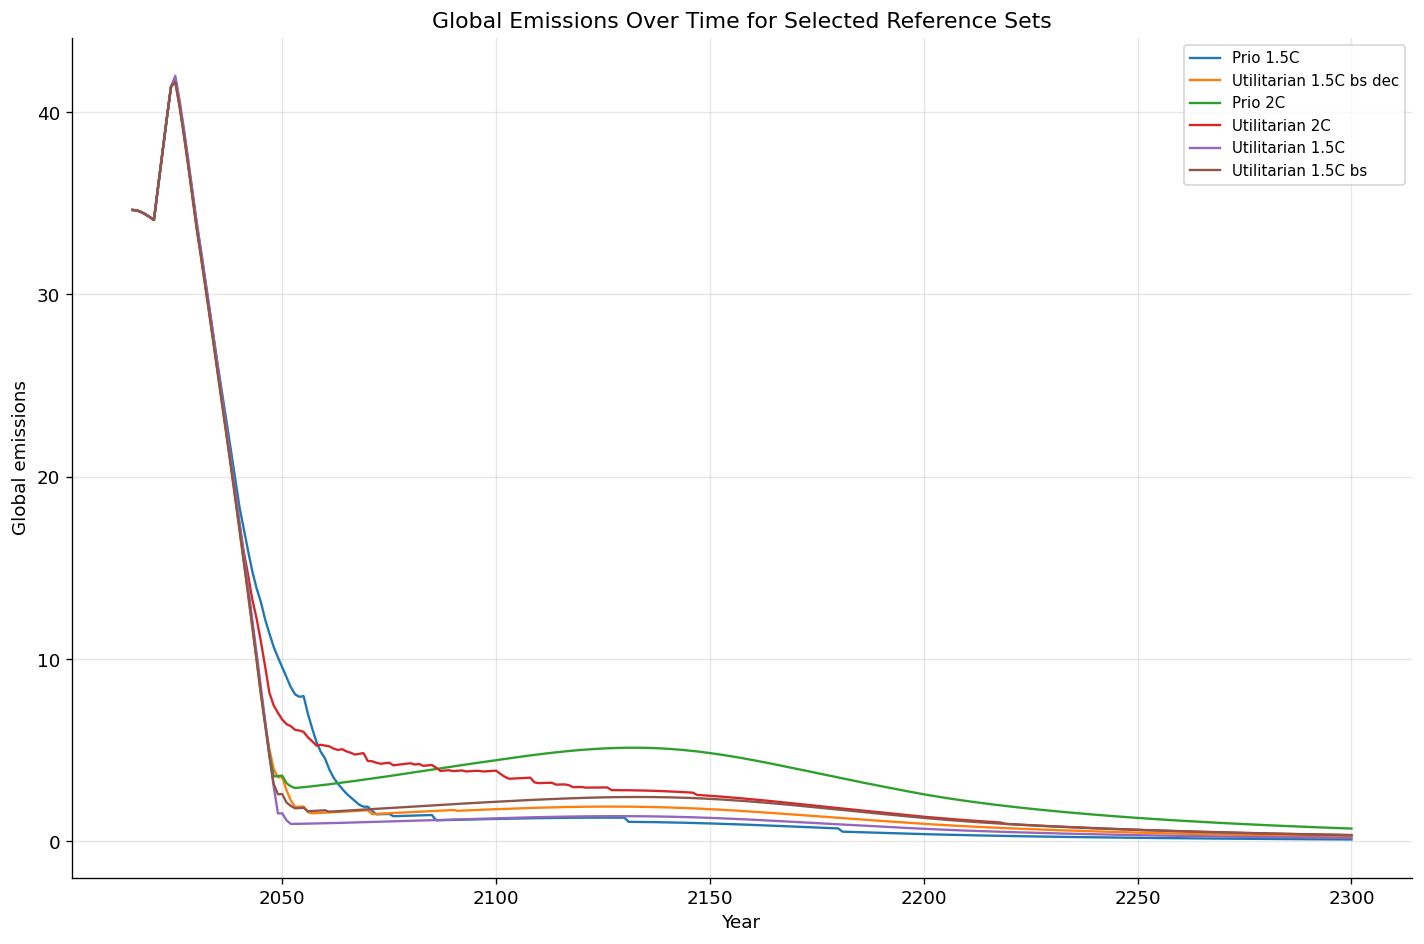

In [ ]:
#Plot 3, global emissions for lowest threshold
fig, ax = plt.subplots(figsize=(12, 8))

for label, result in lowest_threshold_emissions_results.items():
    ax.plot(years, global_emissions(result["datasets"]), linewidth=1.4, label=label)

ax.set_title("Global Emissions Over Time for Selected Reference Sets")
ax.set_xlabel("Year")
ax.set_ylabel("Global emissions")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "global_emissions_reference_sets.png"), dpi=150)
plt.show()

General Findings:
* All the runs show a pattern opposite to the that of the global temperature: really high values at the start which rapidly decline. This opposite effect is to be expected, as the temperature rises a lot of effort is put into reducing emissions to prevent further temperature rises.
* Most runs show a tipping point at ~2050. As the climate goal for 2050 is to reach global net-zero emissions, as defined in the Paris Agreement (https://unfccc.int/process-and-meetings/the-paris-agreement). We can see that we won't reach net zero at 2050 with these run configurations with the threshold exceedance policy, however most configurations do come really close to net zero.
* Almost all runs approach net zero emissions in the long run, with exception of the 2 degrees prioritarian run which might need more  time to approach it.

Run-specific Findings:
* Noticeable is that two runs have higher tipping points for the curve than the others: the prioritarian 1.5 degrees and the utilitarian 2 degrees. The utilitarian 2 degrees has a higher tipping point than the rest as this run is less ambitious, a steep decline is needed for the 2 degrees as well but once the emissions have dropped significantly there are less stimuli to keep rapidly decreasing the emissions and the priority probably shifts to keeping the economy healthy and welfare loss minimal resulting in a less strong decline in emissions. The prioritarian 1.5 is more difficult to interpret. It could have a higher tipping point because a lot of money is flowing from developed Annex II countries to the rest of the Annex I and developing countries. These monetary flows could allow the economies of the other Annex I and developing countries to thrive as they have to spend less of their own money on reducing emissions. Their thriving economies could increase consumption and in turn emissions, therefore slowing down the declining curve. This is hard to say with certainty however.
* Another interesting run is the prioritarian 2 degrees. This run shows that a lower tipping point, even though it is prioritarian. Giving the logic of the higher tipping point of the 1.5 prioritarian, we could argue that in the prioritarian 2 degrees run the ambitions are less high so less money flows from the developed Annex II countries to the developing regions. This would mean that there would be less money available to them, resulting in their economies thriving in a later stage. This would mean that their consumption would increase be postponed, causing less emissions in the short term, but a new wave of emissions when their consumption rises, which starts at ~2060 and slowly declines as the threshold is less strict.
* The three utilitarian 1.5 degrees runs all have a really low tipping point and stay pretty low. One difference is that the two runs with lower backstops both have a slight emission increase after the curve, this could be due to the emission reductions being cheaper, reserving more money for economic growth and consumption resulting in a small emission spike.

# Closer look at the influence of backstop costs & decline rate

We have analysed the impact of combinations of  different welfare lenses, thresholds and backstop (decline rate) configurations on global welfare, temperature and emissions. It has become clear that the utilitarian lens performs better than the utilitarian and that a 1.5 degrees threshold is necessary to approach the 1.5 target, even though it is a lot later than initially aimed for. Within the utilitarian 1.5 degrees runs, there are still 3 options with different backstop configurations. From the past few graphs it was hard to tell the exact effect of the backstop costs decrease and increase in decline rate as on the one hand, the emissions and temperature remain slightly higher, but on the other hand there appears to be no welfare loss difference. Therefore we take a closer look at the abatement costs, which are influenced by the backstop costs and decline rate. As Abatement costs switch to the backstop cost as abatement becomes more expensive than to implement the new technology. Therefore we would expect that a lower backstop and higher decline rate cause the abatement costs to decrease quicker as it becomes cheaper than abatement earlier on.   

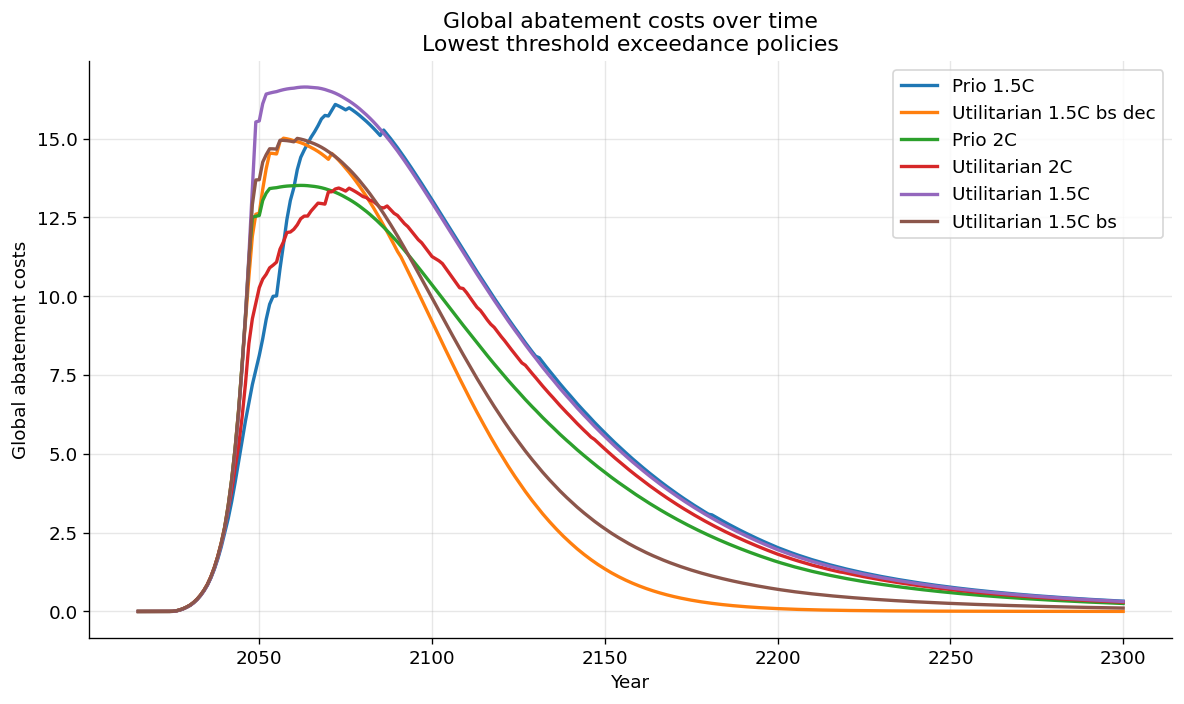

In [ ]:
#Plot 4, abatement costs for lowest threshold
# We created an extra helper function to calculate global abatement costs over time
def global_abatement_costs(datasets):
    abatement = np.asarray(datasets["abatement_cost"])

    if abatement.ndim == 3:
        abatement_over_time = np.nansum(np.nanmean(abatement, axis=2), axis=0)
    elif abatement.ndim == 2:
        abatement_over_time = np.nansum(abatement, axis=0)
    elif abatement.ndim == 1:
        abatement_over_time = abatement
    else:
        raise ValueError(f"Unexpected abatement_cost shape: {abatement.shape}")

    return abatement_over_time


plt.figure(figsize=(10, 6))

for label, result in lowest_threshold_emissions_results.items():
    datasets = result["datasets"]
    abatement_costs = global_abatement_costs(datasets)

    plt.plot(years, abatement_costs, label=label, linewidth=2)

plt.xlabel("Year")
plt.ylabel("Global abatement costs")
plt.title("Global abatement costs over time\nLowest threshold exceedance policies")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

General findings:
* In all runs the abatement costs quickly rise even until after the year 2050, around which most of the emission curve tipping points were. This is caused by the worldwide ECR which plateaus at its peak for an extended period. This causes abatement costs to stay high until we manage to make our consumption more green through innovative technology.
* Eventually, all runs approach 0 global abatement costs.This is probably due to the fact that in all runs, even with higher starting values for the backstop cost or a smaller decline, the backstop costs become relatively free over a 250+ years time period.

Run-specific findings:
* Both 2 degrees runs have an earlier tipping point in the abatement cost curve, they start to flatten out (and decrease) earlier as there is less abatement needed as the temperature goal is less ambitious. This aligns with earlier plots.
* The prioritarian 1.5 degrees run has a less steep increase than the utilitarian 1.5 degrees runs. This is an interesting finding which needs more research.
* Amongst the 1.5 degrees utilitarian runs a big division is visible. Here the difference between a lower initial backstop (200 USD/tCO2) and the regular value (550 USD/tCO2) is strongly visible, as the lower backstop runs flatten out and decrease a lot sooner than the 1.5. This is the effect that we expected: backstop costs become lower than abatement cost, so abatement gets replaced with the backstop cost resulting in less costs.
* The influence of the decline rate is also visible when looking at the 1.5 util runs with lower initial backstops. The brown run without the increased decline rate is pretty similar until they flatten out, after this point the costs decrease a lot slower than the orange run with the increased decline rate. This is expected as the orange run causes the new technology to become cheaper even quicker. Although both runs do outperform the 2 degrees runs at ~2080. So even the less ambitious runs will have higher abatement costs in the long run than more ambitious runs with the backstop policy applied.
* This last finding shows that even though the welfare loss across all utilitarian runs seemed to be the same in an earlier plot, the backstop cost policy succesfully decreases abatement costs leaving more financial power for other purposes. 

# Re-evaluating the chosen policy objective

After having identified:
* the positive welfare effects of the decreased backstop cost and increased decline rate
* positive effects of the utilitarian welfare lens and 1.5 target on the welfare loss, emissions and temperature

We select the orange run to do the rest of the analysis with. The next step is confirming whether the earlier selected anchor policy (the temperature threshold exceedance objective) is still justified when compared with the other anchor policies, given the choice for the orange run.

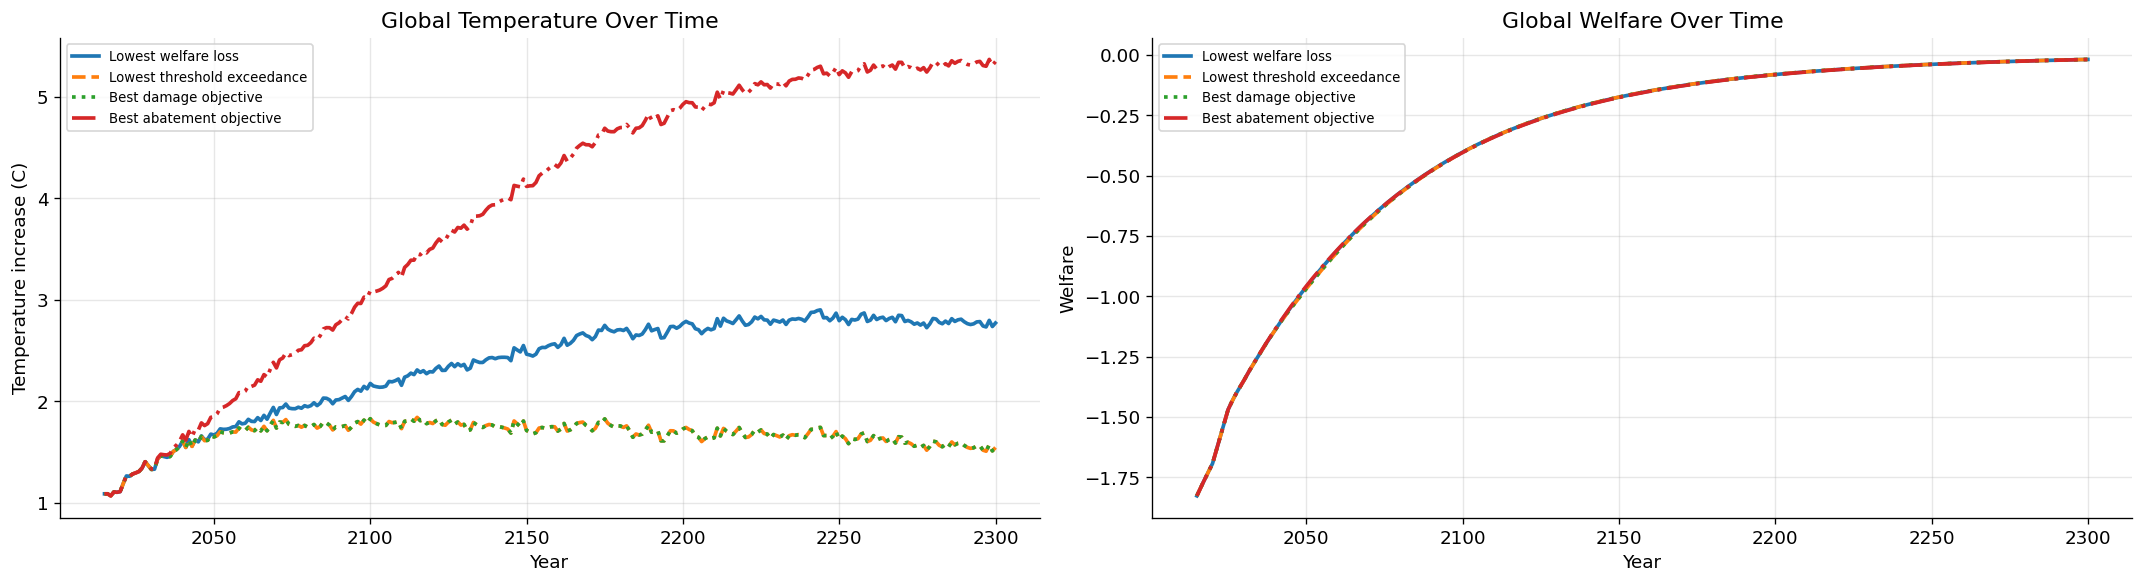

In [ ]:
#Plot 5, global temperature and welfare for all four policies using the most promising run
styles = {
    "Lowest welfare loss": "-",
    "Lowest threshold exceedance": "--",
    "Best damage objective": ":",
    "Best abatement objective": "-.",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)
ax_temp, ax_welfare = axes

for label, result in util_four.items():
    datasets = result["datasets"]
    style = styles.get(label, "--")

    ax_temp.plot(
        years,
        mean_global_temperature(datasets),
        linewidth=2.2,
        linestyle=style,
        label=label,
    )

    ax_welfare.plot(
        years,
        global_welfare(datasets),
        linewidth=2.2,
        linestyle=style,
        label=label,
    )

ax_temp.set_title("Global Temperature Over Time")
ax_temp.set_ylabel("Temperature increase (C)")

ax_welfare.set_title("Global Welfare Over Time")
ax_welfare.set_ylabel("Welfare")

for ax in axes:
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, "temperature_welfare_4_policies_utilitarian_main_bs200.png"),
    dpi=150,
)
plt.show()

Global Temperature Findings:
* The lowest threshold exceedence policy also performs best on the global temperature metric for our selected run configuration, this is as expected as they are directly linked to each other.
* The policy that optimises for the best damage objective also scores well on the global temperature, this is probably due to the fact that less damage is caused by global warming when the temperature is at its lowest.
* Optimising for the abatement objective and the lowest welfare loss score really badly on the temperature. The abatement objectives policy probably scores badly as abatement costs are minimised under this policy, resulting in a lot of emissions which allow the temperature to increase drastically. The lowest welfare loss probably scores in the middle as on the one hand abatement is necessary to make sure that damage loss due to climate change stay low, on the other hand the abatement costs must not get too high.

Welfare Findings:
* Again all policies score the same on global welfare, which is something that could use further investigation.

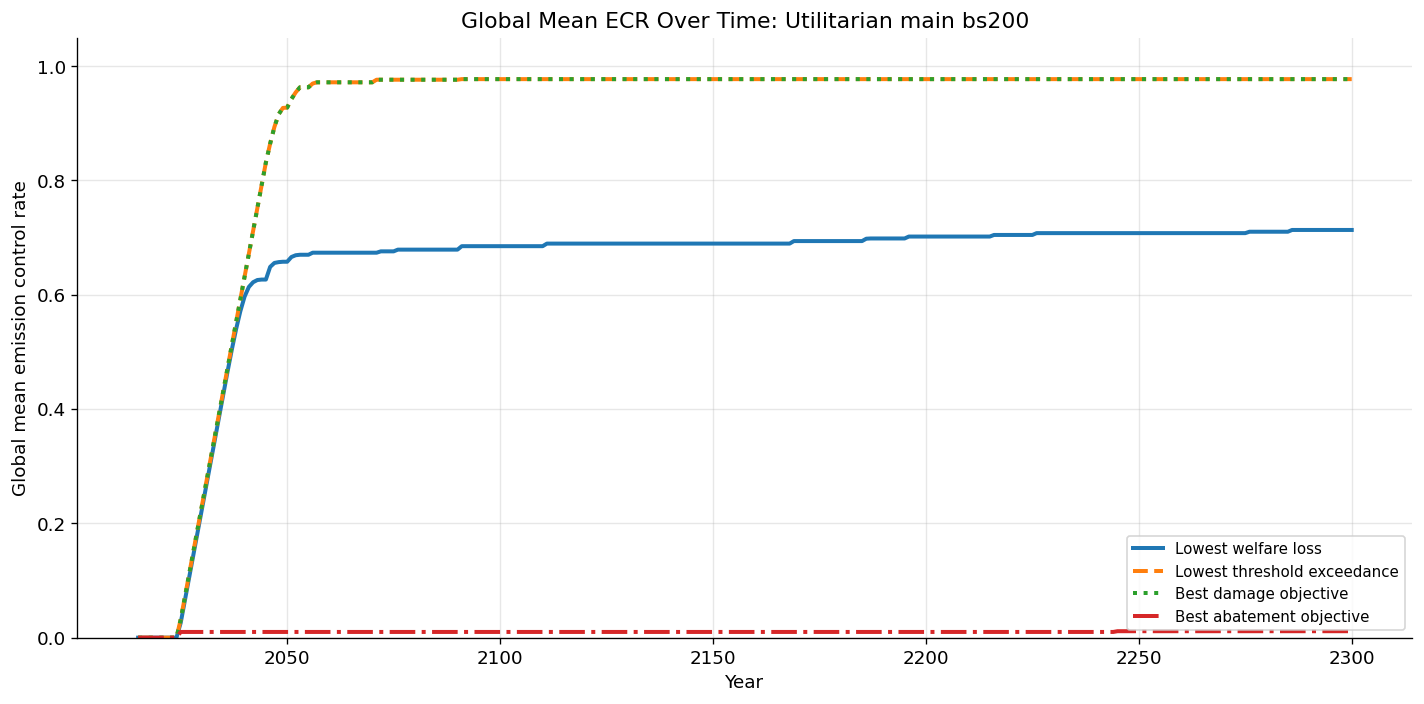

In [ ]:
#Plot 6, global mean ECR over time, four policies
styles = {
    "Lowest welfare loss": "-",
    "Lowest threshold exceedance": "--",
    "Best damage objective": ":",
    "Best abatement objective": "-.",
}

fig, ax = plt.subplots(figsize=(12, 6))

for label, result in util_four.items():
    ax.plot(
        years,
        mean_global_ecr(result["ecr"]),
        linewidth=2.4,
        linestyle=styles.get(label, "--"),
        label=label,
    )

ax.set_title("Global Mean ECR Over Time: Utilitarian main bs200")
ax.set_xlabel("Year")
ax.set_ylabel("Global mean emission control rate")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, "ecr_4_policies_utilitarian_main_bs200.png"),
    dpi=150,
)
plt.show()

Findings:
* The abatement policy again scores really low on the ECR, which is positive from a short-term economical viewpoint as you spend you money, but in the long run a lot of damage loss will be acquired.
* Given the same logic as for the last graph, the lowest welfare loss policy scores in the middle-of-the-road.
* The best damage objective and the lowest threshold exceedance have the same ECR rate, a really high one. This resonates with their positive effect on the global temperature.

Conclusion: The threshold exceedance policy scores together with the best damage policy outperforms the other two policies on temperature and welfare. This validates the choice  for the threshold exceedance policy. As the red line for the UK is the temperature threshold, we still stick to the threshold policy for the last part of the analysis.

# Implications for the Global and UK emission trajectories

Now that we have identified the anchor policy and run configuration, we can analyse the impact for the global and UK emission trajectories and see whether we meet our stated commitments, or whether there is still a policy gap.

ANALYSE FOR PREFERRED SOLUTION: Utilitarian 1.5C bs dec
GBR Total Emissions 2020: 0.336 GtCO2/year
GBR Total Emissions 2050: 0.020 GtCO2/year
Gap Analysis: GBR retains 5.8% of its emissions base in 2050.
Absolute Gap: 19.5 MtCO2/year remaining.


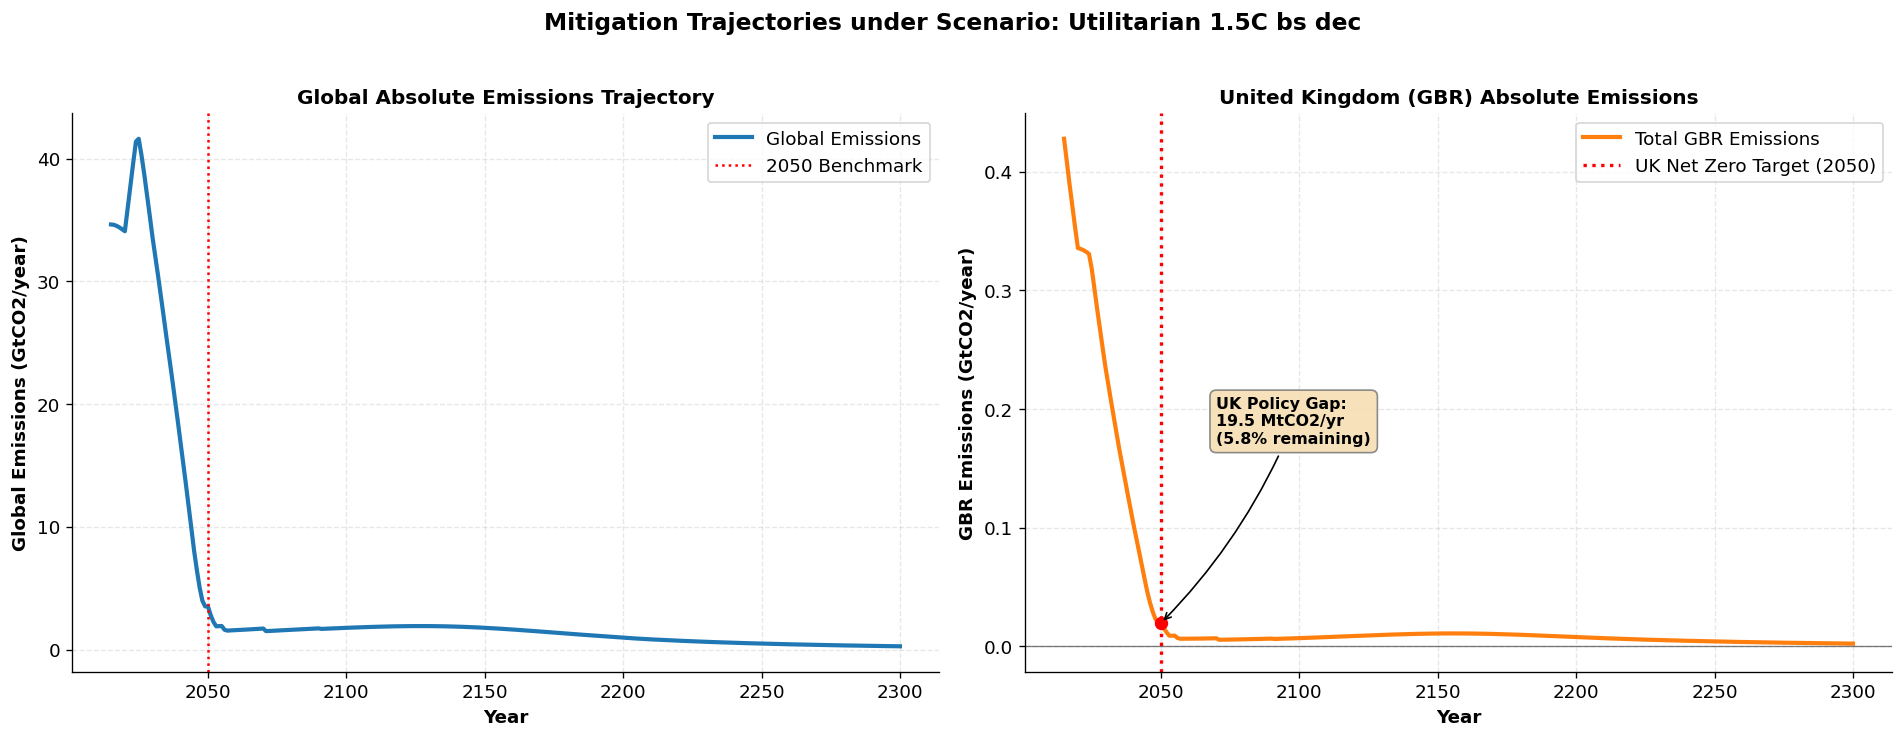

In [ ]:
#Plot 7, global and UK emissions for preferred solution

#First the right dataset is selected
preferred_scenario = "Utilitarian 1.5C bs dec"
datasets_run = lowest_threshold_emissions_results[preferred_scenario]["datasets"]

gbr_idx = find_gbr_index()

emissions_data = np.asarray(datasets_run["emissions"])

#extracting the GBR and global emissions from the dataset, depending on the shape of the emissions data
if emissions_data.ndim == 3:
    emissions_clean = np.nanmean(emissions_data, axis=2)
    gbr_emissions = emissions_clean[gbr_idx, :]
    world_emissions = np.nansum(emissions_clean, axis=0)
else:
    world_emissions = emissions_data.sum(axis=0) if emissions_data.ndim == 2 else datasets_run["global_emissions"]
    gbr_emissions = emissions_data[gbr_idx, :] if emissions_data.ndim == 2 else emissions_data

# Calculating the policy gap in perfectage and absolute
idx_2020 = np.where(years == 2020)[0][0] if 2020 in years else 0
idx_2050 = np.where(years == 2050)[0][0]

emissions_start_gbr = float(gbr_emissions[idx_2020])
emissions_2050_gbr = float(gbr_emissions[idx_2050])
pct_remaining_2050 = (emissions_2050_gbr / emissions_start_gbr) * 100

print(f"ANALYSE FOR PREFERRED SOLUTION: {preferred_scenario}")
print(f"GBR Total Emissions 2020: {emissions_start_gbr:.3f} GtCO2/year")
print(f"GBR Total Emissions 2050: {emissions_2050_gbr:.3f} GtCO2/year")
print(f"Gap Analysis: GBR retains {pct_remaining_2050:.1f}% of its emissions base in 2050.")
print(f"Absolute Gap: {emissions_2050_gbr*1000:.1f} MtCO2/year remaining.")

# From here on we create the figure with two subplots, one for global emissions and one for GBR emissions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

#Left plot, global
ax1.plot(years, world_emissions, color='#1f77b4', linewidth=2.5, label='Global Emissions')
ax1.axvline(x=2050, color='red', linestyle=':', linewidth=1.5, label='2050 Benchmark')
ax1.set_title("Global Absolute Emissions Trajectory", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year", fontweight='bold')
ax1.set_ylabel("Global Emissions (GtCO2/year)", fontweight='bold')
ax1.grid(True, linestyle="--", alpha=0.3)
ax1.legend(loc='upper right')

#Right plot, GBR/UK
ax2.plot(years, gbr_emissions, color='#ff7f0e', linewidth=2.5, label='Total GBR Emissions')
ax2.axvline(x=2050, color='red', linestyle=':', linewidth=2, label='UK Net Zero Target (2050)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

#To highlight the policy gap
ax2.plot(2050, emissions_2050_gbr, marker='o', color='red', markersize=7)
ax2.annotate(
    f"UK Policy Gap:\n{emissions_2050_gbr*1000:.1f} MtCO2/yr\n({pct_remaining_2050:.1f}% remaining)",
    xy=(2050, emissions_2050_gbr),
    xytext=(2070, max(gbr_emissions) * 0.4),  # Automatically spaces the text frame cleanly
    arrowprops=dict(facecolor='black', arrowstyle="->", connectionstyle="arc3,rad=-0.1"),
    bbox=dict(boxstyle="round,pad=0.4", facecolor='wheat', alpha=0.9, edgecolor='grey'),
    fontsize=9.5,
    fontweight='bold'
)

ax2.set_title("United Kingdom (GBR) Absolute Emissions", fontsize=12, fontweight='bold')
ax2.set_xlabel("Year", fontweight='bold')
ax2.set_ylabel("GBR Emissions (GtCO2/year)", fontweight='bold')
ax2.grid(True, linestyle="--", alpha=0.3)
ax2.legend(loc='upper right')

plt.suptitle(f"Mitigation Trajectories under Scenario: {preferred_scenario}", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Global findings:
* The Goal of global net zero emissions still increase and spike at 2025. However, from here on they strongly decrease. This is due to the fact that the ecr policy start year is set to 2025. The goal of reaching global net-zero in 2050 is not met, so a global policy gap remains. However, the global emissions do drop to just a few gigatons CO2/year, coming from 35 gigatons in 2015 and more than 40 in 2025 this is a significant decrease. Global net zero emissions will however only be reached at about 2300 as they only slowly decrease from 2050 onward.

UK/GBR findings:
* The emission trajectory from the UK follows a similar pattern as the global ECR trajectory without the increase until 2025. The 2050 net-zero target is not met either. However, only 5.8% of the emission level of 2015 remains in 2050, representing an emission cut of almost 95% which is even more significant than the cut in global emissions. After 2050, the UK emissions follow a similar slight decrease until they reach net-zero in 2300.

# Robustness of policy


Loaded reference set: c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results\reference_set_utilitarian_1_5_bs200_dec0101.csv
Loaded re-evaluation results: c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results\reeval_utilitarian_bs200_dec0101_12p_1000s.npy
Shape: 12 policies x 1000 scenarios x 4 objectives


,objective,threshold,direction
0,welfare,103.610518,lower is better
1,years_above_2C,87.000000,lower is better
2,welfare_loss_damage,3973.525810,lower is better
3,welfare_loss_abatement,11101.515435,lower is better


,objective,threshold,fraction_meeting_threshold
1,years_above_2C,87.000000,0.250083
0,welfare,103.610518,0.500000
2,welfare_loss_damage,3973.525810,0.500000
3,welfare_loss_abatement,11101.515435,0.500000


,policy_index,policy_label,Welfare loss,Years above 2C,Damage welfare loss,Abatement welfare loss,overall_satisficing_score
0,8,P8,0.505,0.429,0.497,1.000,0.125
1,6,P6,0.432,0.419,0.494,1.000,0.118
2,0,P0,0.313,0.463,0.491,1.000,0.082
3,11,P11,0.224,0.487,0.491,1.000,0.044
4,7,P7,0.219,0.534,0.481,0.942,0.042
5,1,P1,0.173,0.539,0.487,1.000,0.023
6,3,P3,0.494,0.000,0.522,0.000,0.000
7,2,P2,0.774,0.032,0.504,0.000,0.000
8,4,P4,0.715,0.001,0.511,0.000,0.000
9,5,P5,0.733,0.041,0.504,0.000,0.000


,policy_index,policy_label,maximum_regret,mean_regret,satisficing_score
0,2,P2,1.861349,1.244632,0.000
1,9,P9,1.862883,1.255019,0.000
2,4,P4,1.919574,1.281761,0.000
3,5,P5,1.935332,1.353139,0.000
4,10,P10,2.069498,1.427016,0.000
5,8,P8,2.436006,1.495367,0.125
6,7,P7,2.498146,1.799939,0.042
7,6,P6,2.503985,1.635247,0.118
8,0,P0,2.665905,1.751439,0.082
9,11,P11,2.691454,1.849972,0.044


Minimax-regret policy: P2
Best satisficing policy: P8

Summary:
Mean satisficing score: 0.036
Maximum satisficing score: 0.125
Policies with zero satisficing score: 6


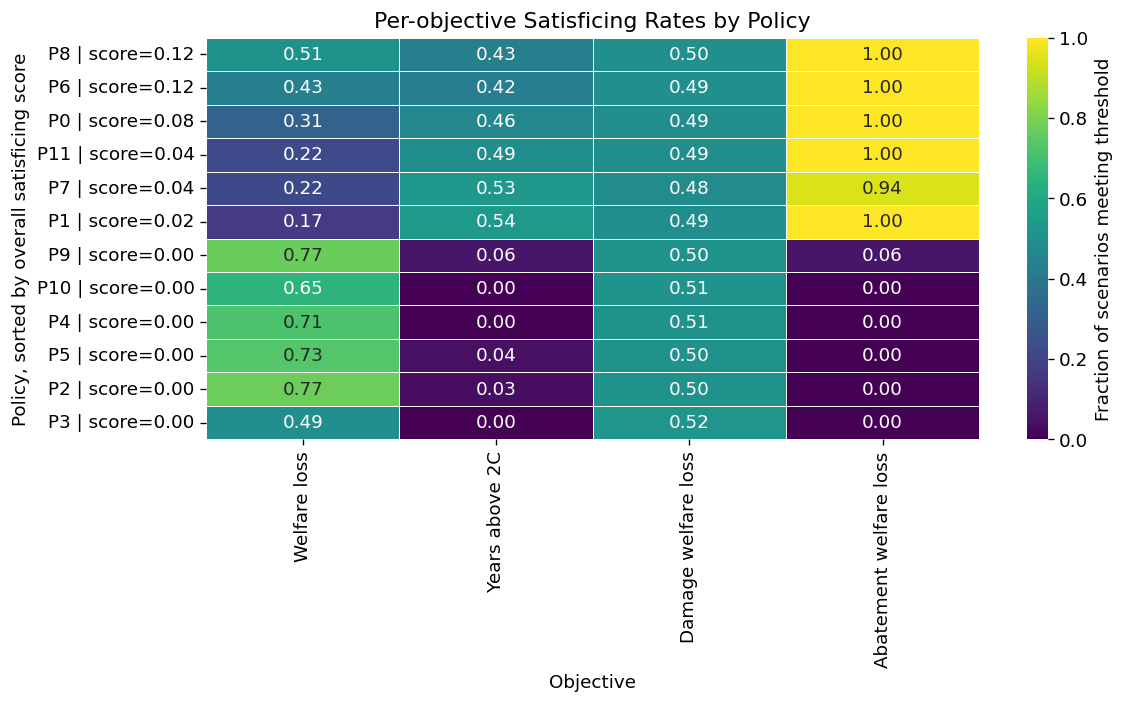

In [ ]:
# Set path for the chosen ref set
ref_path = os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_bs200_dec0101.csv")

# Set path for the re-evaluation results
reeval_path = os.path.join(
    RESULTS_DIR,
    "reeval_utilitarian_bs200_dec0101_12p_1000s.npy",
)

ref_set = pd.read_csv(ref_path)
ref_set.columns = ref_set.columns.str.strip().str.replace(" ", "_")

reeval_results = np.load(reeval_path)

#define the objectives and lables for plotting + analysis
OBJECTIVES = [
    "welfare",
    "years_above_2C",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

objective_labels = {
    "welfare": "Welfare loss",
    "years_above_2C": "Years above 2C",
    "welfare_loss_damage": "Damage welfare loss",
    "welfare_loss_abatement": "Abatement welfare loss",
}

n_policies, n_scenarios, n_objectives = reeval_results.shape

print(f"Loaded reference set: {ref_path}")
print(f"Loaded re-evaluation results: {reeval_path}")
print(f"Shape: {n_policies} policies x {n_scenarios} scenarios x {n_objectives} objectives")

# Here we define the thresholds
# All objectives are minimised, so lower = better
thresholds = {
    "welfare": np.nanpercentile(
        reeval_results[:, :, OBJECTIVES.index("welfare")],
        50, #This threshold is set to the median as it is important, but not as important as the threshold exceedance
    ),
    "years_above_2C": np.nanpercentile(
        reeval_results[:, :, OBJECTIVES.index("years_above_2C")],
        25, #This threshold is set to the 25th percentile as it is the most important objective and we want to be more strict on it
    ),
    "welfare_loss_damage": np.nanpercentile(
        reeval_results[:, :, OBJECTIVES.index("welfare_loss_damage")],
        50, #Same as for the welfare loss, welfare is important but less than the threshold
    ),
    "welfare_loss_abatement": np.nanpercentile(
        reeval_results[:, :, OBJECTIVES.index("welfare_loss_abatement")],
        50, #Same as for the welfare loss, welfare is important but less than the threshold
    ),
}

threshold_array = np.array([thresholds[obj] for obj in OBJECTIVES])

threshold_table = pd.DataFrame({
    "objective": OBJECTIVES,
    "threshold": threshold_array,
    "direction": "lower is better",
})

display(threshold_table)

# Calculate which policy-scenario runs meet the thresholds for each objective
meets_objective = reeval_results <= threshold_array

#A policy satisfices in a scenario only if it meets all objective thresholds
satisficing_matrix = meets_objective.all(axis=2)

satisficing_scores = satisficing_matrix.mean(axis=1)

per_objective_rate = meets_objective.mean(axis=(0, 1))

per_objective_table = pd.DataFrame({
    "objective": OBJECTIVES,
    "threshold": threshold_array,
    "fraction_meeting_threshold": per_objective_rate,
}).sort_values("fraction_meeting_threshold")

display(per_objective_table)

# Table of per-policy satisficing rates for each objective
policy_objective_rates = meets_objective.mean(axis=1)

policy_objective_satisficing_table = pd.DataFrame(
    policy_objective_rates,
    columns=[objective_labels[obj] for obj in OBJECTIVES],
)

policy_objective_satisficing_table.insert(
    0,
    "policy_label",
    [f"P{i}" for i in range(n_policies)],
)

policy_objective_satisficing_table.insert(
    0,
    "policy_index",
    np.arange(n_policies),
)

policy_objective_satisficing_table["overall_satisficing_score"] = satisficing_scores

policy_objective_satisficing_table = policy_objective_satisficing_table.sort_values(
    "overall_satisficing_score",
    ascending=False,
).reset_index(drop=True)

display(policy_objective_satisficing_table)

# Minimax regret analysis
# ideal = best value per scenario/objective
# anti_ideal = worst value per scenario/objective
ideal = np.nanmin(reeval_results, axis=0)
anti_ideal = np.nanmax(reeval_results, axis=0)

regret_range = anti_ideal - ideal
regret_range = np.where(regret_range == 0, 1.0, regret_range)

normalised_regret = (reeval_results - ideal) / regret_range
normalised_regret = np.clip(normalised_regret, 0, 1)

total_regret = normalised_regret.sum(axis=2)

maximum_regret = np.nanmax(total_regret, axis=1)

mean_regret = np.nanmean(total_regret, axis=1)

# This is to create the final tabel containing both minimax and satisfice
robustness_table = pd.DataFrame({
    "policy_index": np.arange(n_policies),
    "policy_label": [f"P{i}" for i in range(n_policies)],
    "maximum_regret": maximum_regret,
    "mean_regret": mean_regret,
    "satisficing_score": satisficing_scores,
}).sort_values("maximum_regret").reset_index(drop=True)

display(robustness_table)

minimax_policy_idx = int(robustness_table.loc[0, "policy_index"])
best_satisficing_idx = int(
    robustness_table.sort_values("satisficing_score", ascending=False).iloc[0]["policy_index"]
)

print(f"Minimax-regret policy: P{minimax_policy_idx}")
print(f"Best satisficing policy: P{best_satisficing_idx}")

print("\nSummary:")
print(f"Mean satisficing score: {satisficing_scores.mean():.3f}")
print(f"Maximum satisficing score: {satisficing_scores.max():.3f}")
print(f"Policies with zero satisficing score: {(satisficing_scores == 0).sum()}")

# Heatmap of the satisficing scores
sort_idx = np.argsort(satisficing_scores)[::-1]

heatmap_df = pd.DataFrame(
    policy_objective_rates[sort_idx],
    columns=[objective_labels[obj] for obj in OBJECTIVES],
    index=[f"P{i} | score={satisficing_scores[i]:.2f}" for i in sort_idx],
)

plt.figure(figsize=(10, max(6, 0.35 * n_policies)))
sns.heatmap(
    heatmap_df,
    vmin=0,
    vmax=1,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Fraction of scenarios meeting threshold"},
)

plt.title("Per-objective Satisficing Rates by Policy")
plt.xlabel("Objective")
plt.ylabel("Policy, sorted by overall satisficing score")
plt.tight_layout()
plt.show()

The robustness results show that the lowest-threshold policy performs only moderately on the overall satisficing score across all objectives. As expected, it performs very well on the climate objective, with a high satisficing score for years above the temperature threshold. However, its satisficing score for welfare is relatively low. This does not necessarily invalidate the policy, but it highlights an important trade-off: prioritising strict temperature control can come at the expense of welfare performance.

For the UK, this trade-off may still be defensible when using a utilitarian welfare lens, where the aim is to maximise aggregate social utility. Under a prioritarian welfare framework, however, such a policy could be more problematic, because the welfare losses may fall more heavily on already vulnerable groups or regions. In addition, the policy performs poorly on minimax regret, ranking 10th out of 15 policies, which suggests that it is not among the most robust options under deep uncertainty.

Therefore, while the lowest-threshold policy can be justified on climate grounds, its robustness is limited. This should be explicitly acknowledged in the limitations: the policy strongly supports the climate objective, but it is less robust when broader welfare and regret-based criteria are considered.


# Extra plots

These are extra plots we made during our research that helped us understand the system or helped our argumentation during the debate. They were however not that relevant for our report storyline and are therefore kept in this section.

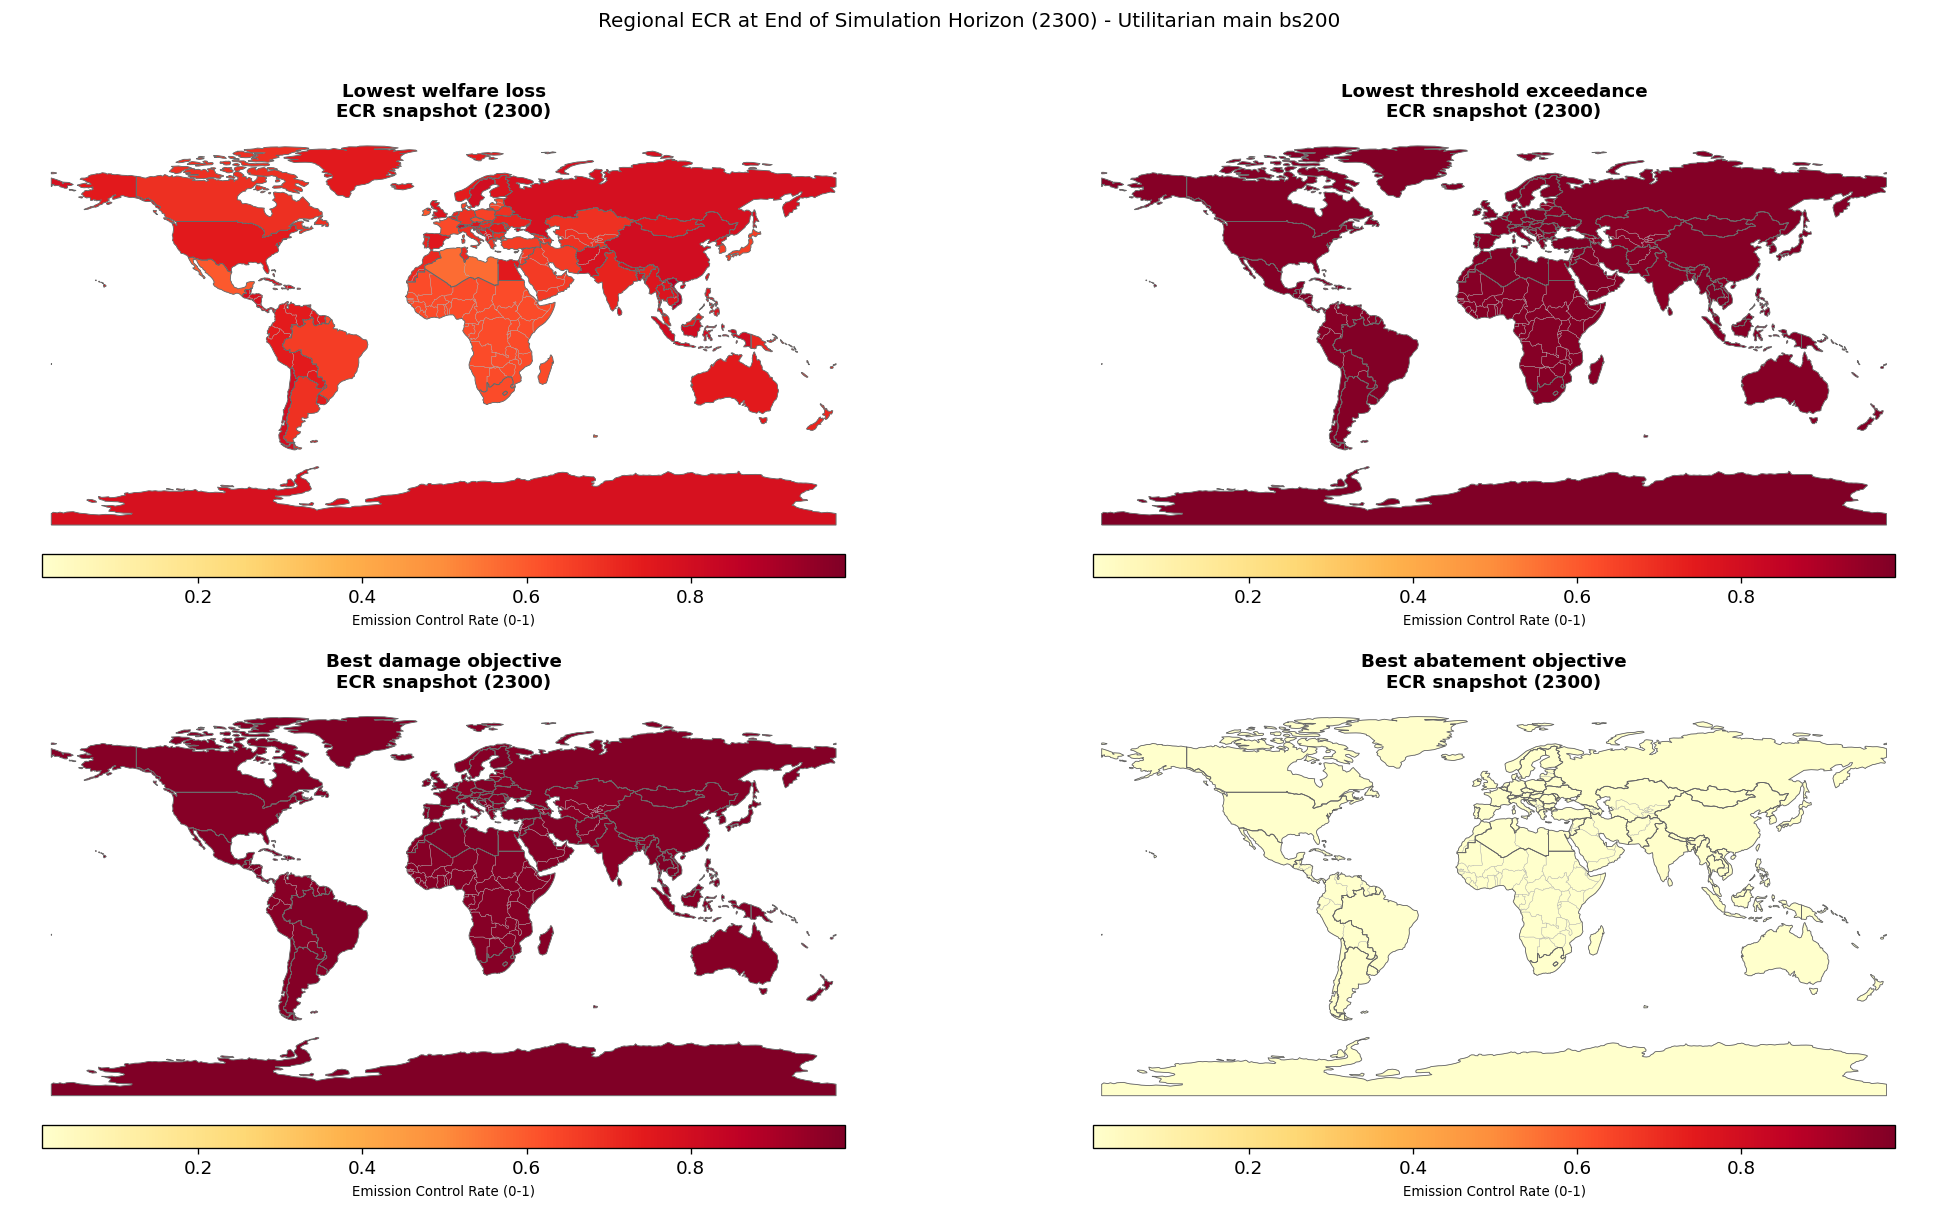

In [ ]:
rice50_path = os.path.join(JUSTICE_ROOT, "data", "input", "rice50_regions_dict.json")
with open(rice50_path) as fh:
    rice50_dict = json.load(fh)

iso_to_rice50 = {
    iso: region
    for region, isos in rice50_dict.items()
    for iso in isos
}

name_fallback = {
    "France": "fra",
    "Norway": "nor",
    "Kosovo": "oeu",
    "N. Cyprus": "tur",
    "Somaliland": "rsaf",
}

t_end = N_TIMESTEPS - 1
snap_year = int(years[t_end])

ecr_end = {
    label: {REGION_LIST[i]: result["ecr"][i, t_end] for i in range(N_REGIONS)}
    for label, result in util_four.items()
}

pyogrio_path = pathlib.Path(importlib.util.find_spec("pyogrio").origin).parent
ne_shp = str(pyogrio_path / "tests" / "fixtures" / "naturalearth_lowres" / "naturalearth_lowres.shp")

world = gpd.read_file(ne_shp)
world["rice50"] = world["iso_a3"].map(iso_to_rice50)
missing = world["rice50"].isna()
world.loc[missing, "rice50"] = world.loc[missing, "name"].map(name_fallback)

for label, region_ecr in ecr_end.items():
    world[f"ecr_{label}"] = world["rice50"].map(region_ecr)

ecr_cols = [f"ecr_{label}" for label in ecr_end]
regions_gdf = (
    world[world["rice50"].notna()]
    .dissolve(by="rice50", aggfunc="first")
    .reset_index()
)[["rice50", "geometry"] + ecr_cols]

regions_gdf = gpd.GeoDataFrame(regions_gdf, geometry="geometry", crs=world.crs)

panel_specs = [(f"ecr_{label}", f"{label}\nECR snapshot ({snap_year})") for label in ecr_end]
all_vals = pd.concat([regions_gdf[col].dropna() for col, _ in panel_specs])

cmap = plt.cm.YlOrRd
norm = mcolors.Normalize(vmin=all_vals.min(), vmax=all_vals.max())

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, panel_specs):
    world.plot(ax=ax, color="0.88")
    world.boundary.plot(ax=ax, color="0.7", linewidth=0.2)

    regions_gdf.plot(
        ax=ax,
        color=[cmap(norm(v)) if pd.notna(v) else "0.88" for v in regions_gdf[col]],
    )
    regions_gdf.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.02, shrink=0.75, aspect=35)
    cbar.set_label("Emission Control Rate (0-1)", fontsize=8)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_axis_off()

fig.suptitle(
    f"Regional ECR at End of Simulation Horizon ({snap_year}) - Utilitarian main bs200",
    fontsize=12,
    y=1.01,
)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "ecr_regional_map_utilitarian_main_bs200.png"), dpi=150, bbox_inches="tight")
plt.show()

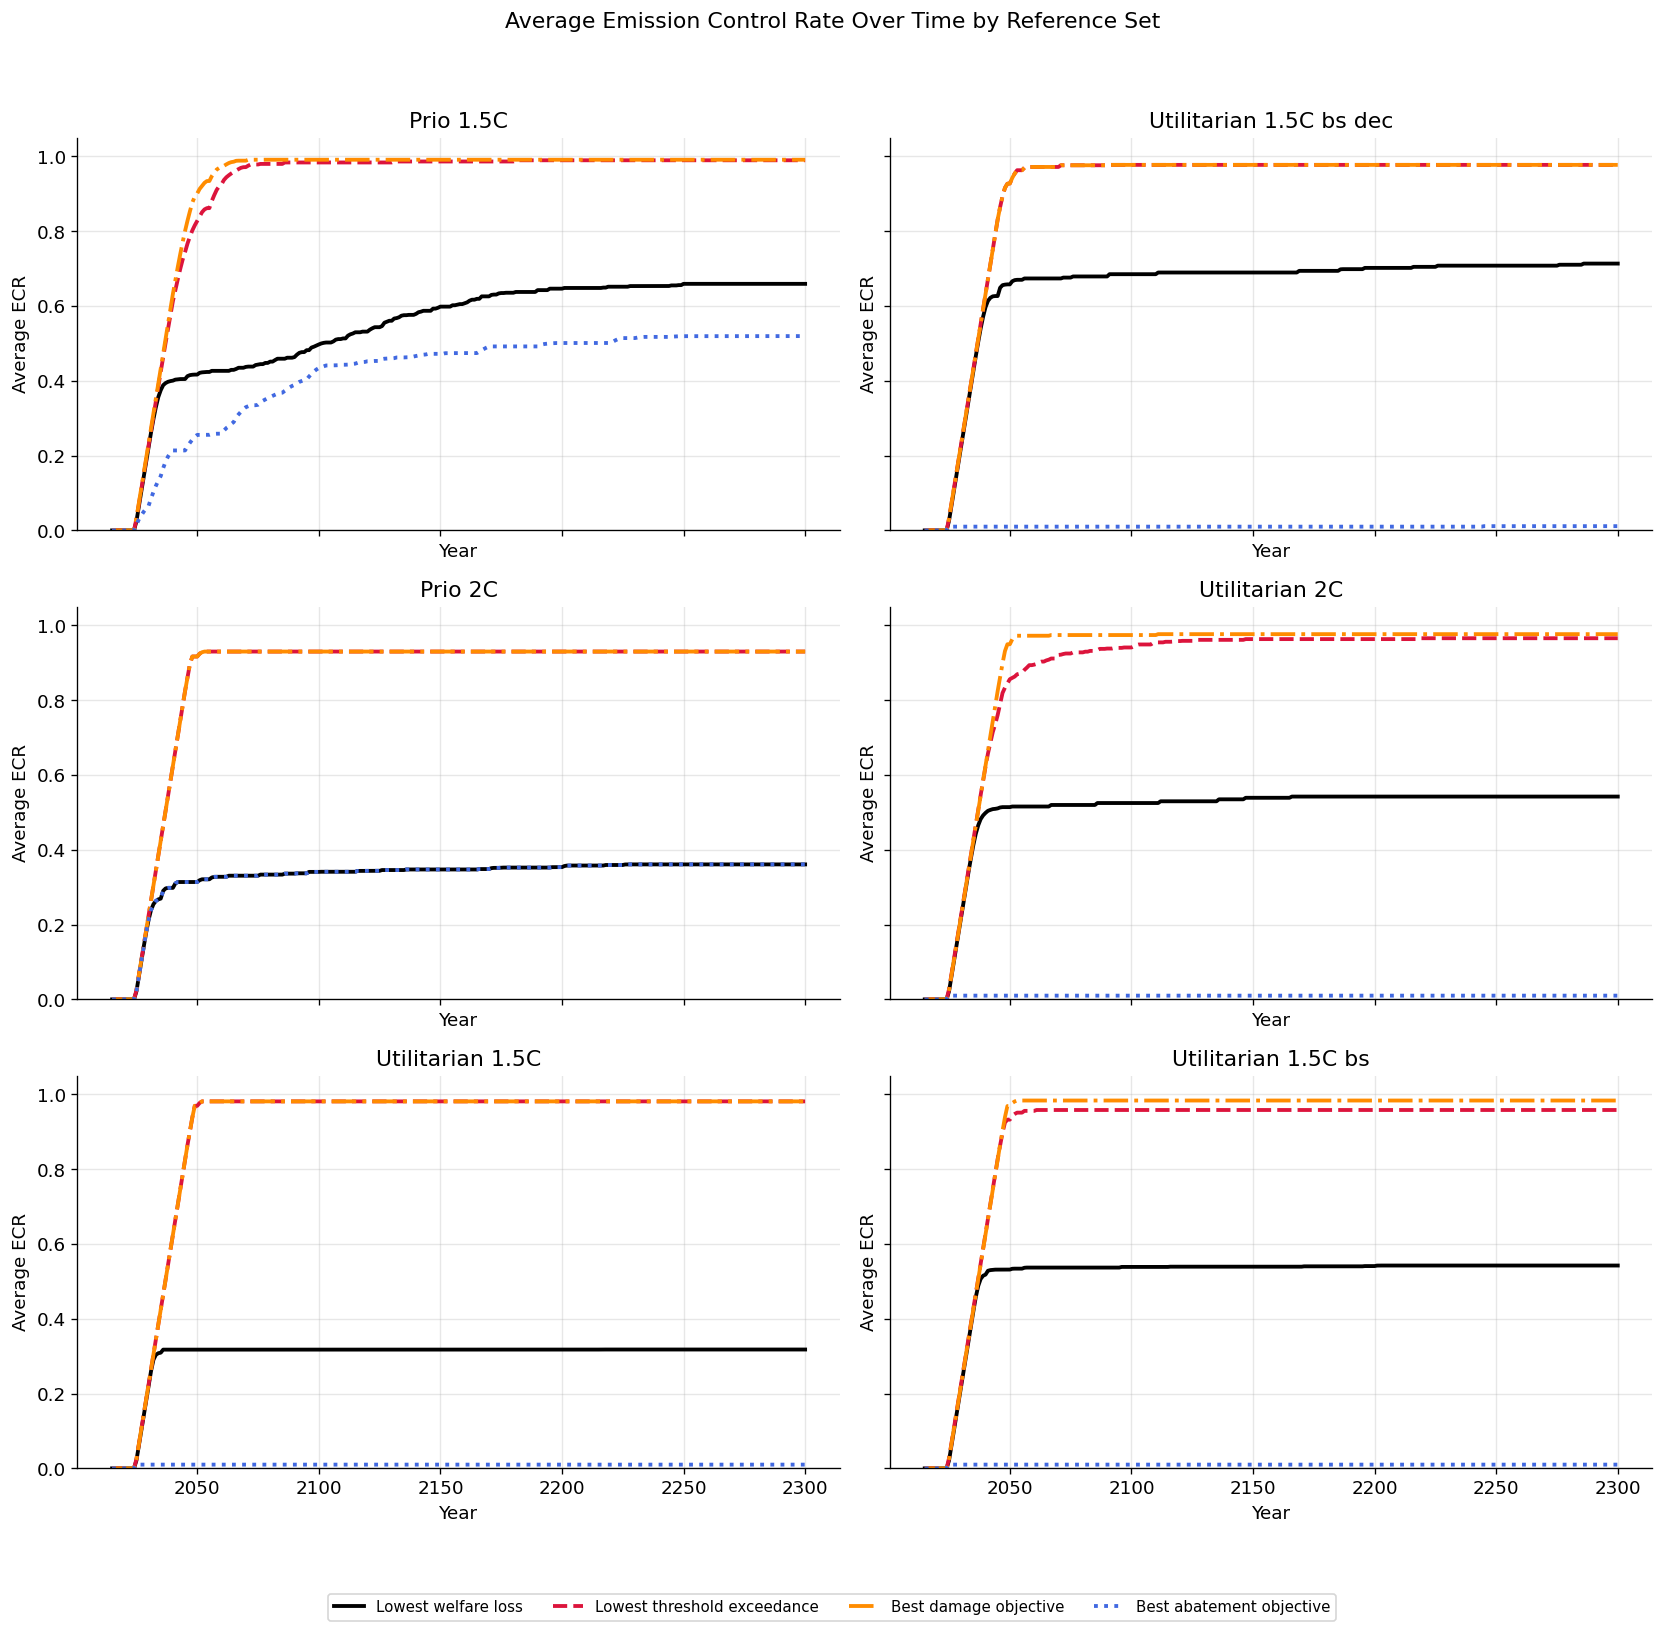

In [ ]:
# average ECR over time by reference set, four policies each
styles = {
    "Lowest welfare loss": "-",
    "Lowest threshold exceedance": "--",
    "Best damage objective": "-.",
    "Best abatement objective": ":",
}

colors = {
    "Lowest welfare loss": "black",
    "Lowest threshold exceedance": "crimson",
    "Best damage objective": "darkorange",
    "Best abatement objective": "royalblue",
}

n_refs = len(ecr_by_refset_results)
ncols = 2
nrows = int(np.ceil(n_refs / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 4.5 * nrows),
    sharex=True,
    sharey=True,
)

axes = np.atleast_1d(axes).flatten()

for ax, (ref_label, policy_results) in zip(axes, ecr_by_refset_results.items()):
    for policy_label, result in policy_results.items():
        ax.plot(
            years,
            mean_global_ecr(result["ecr"]),
            linewidth=2.3,
            linestyle=styles.get(policy_label, "-"),
            color=colors.get(policy_label, None),
            label=policy_label,
        )

    ax.set_title(ref_label)
    ax.set_xlabel("Year")
    ax.set_ylabel("Average ECR")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

# Hide unused subplot panels
for ax in axes[n_refs:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9)

fig.suptitle("Average Emission Control Rate Over Time by Reference Set", y=0.995)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])

plt.savefig(
    os.path.join(PLOTS_DIR, "ecr_over_time_four_policies_by_reference_set.png"),
    dpi=150,
)
plt.show()

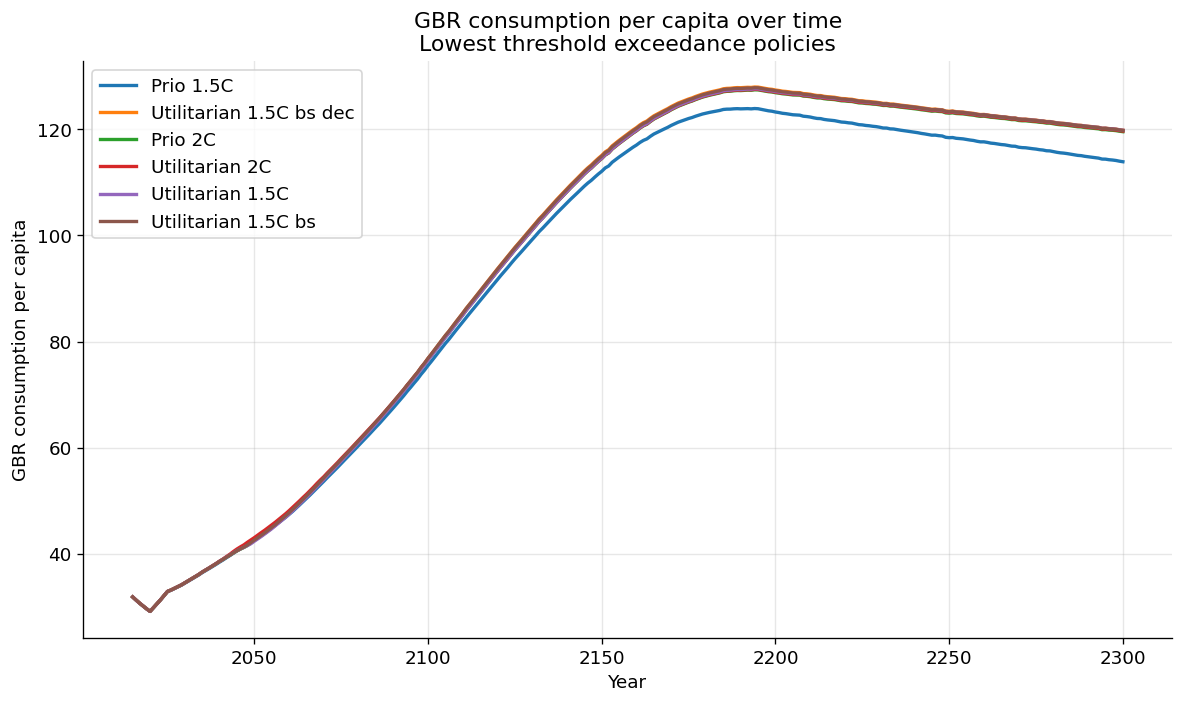

In [ ]:
# gbr consumption per capita
plt.figure(figsize=(10, 6))

for label, result in lowest_threshold_emissions_results.items():
    datasets = result["datasets"]
    plt.plot(years, gbr_consumption_per_capita(datasets), label=label, linewidth=2)

plt.xlabel("Year")
plt.ylabel("GBR consumption per capita")
plt.title("GBR consumption per capita over time\nLowest threshold exceedance policies")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

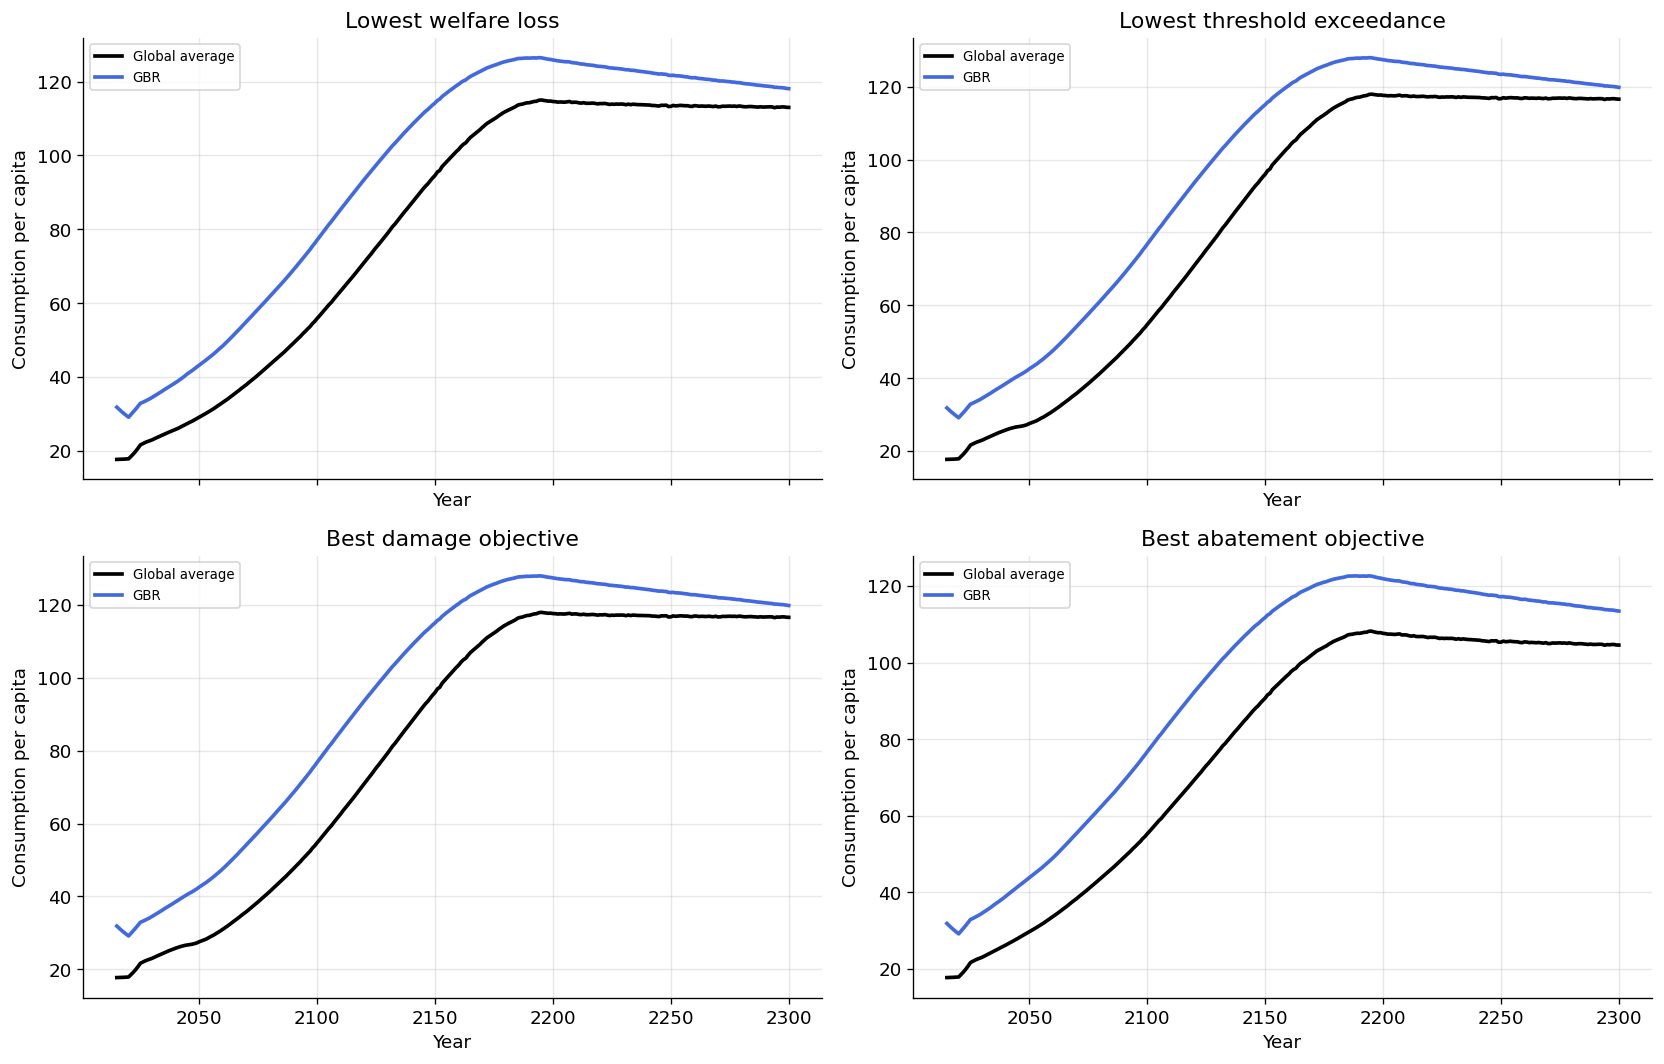

In [ ]:
# consumption per capita, global average vs GBR for all four policies
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax, (label, result) in zip(axes, util_four.items()):
    datasets = result["datasets"]

    ax.plot(years, global_avg_consumption_per_capita(datasets), label="Global average", color="black", linewidth=2.2)
    ax.plot(years, gbr_consumption_per_capita(datasets), label="GBR", color="royalblue", linewidth=2.2)

    ax.set_title(label)
    ax.set_ylabel("Consumption per capita")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("Year")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "consumption_per_capita_global_vs_gbr_utilitarian_main_bs200.png"), dpi=150)
plt.show()

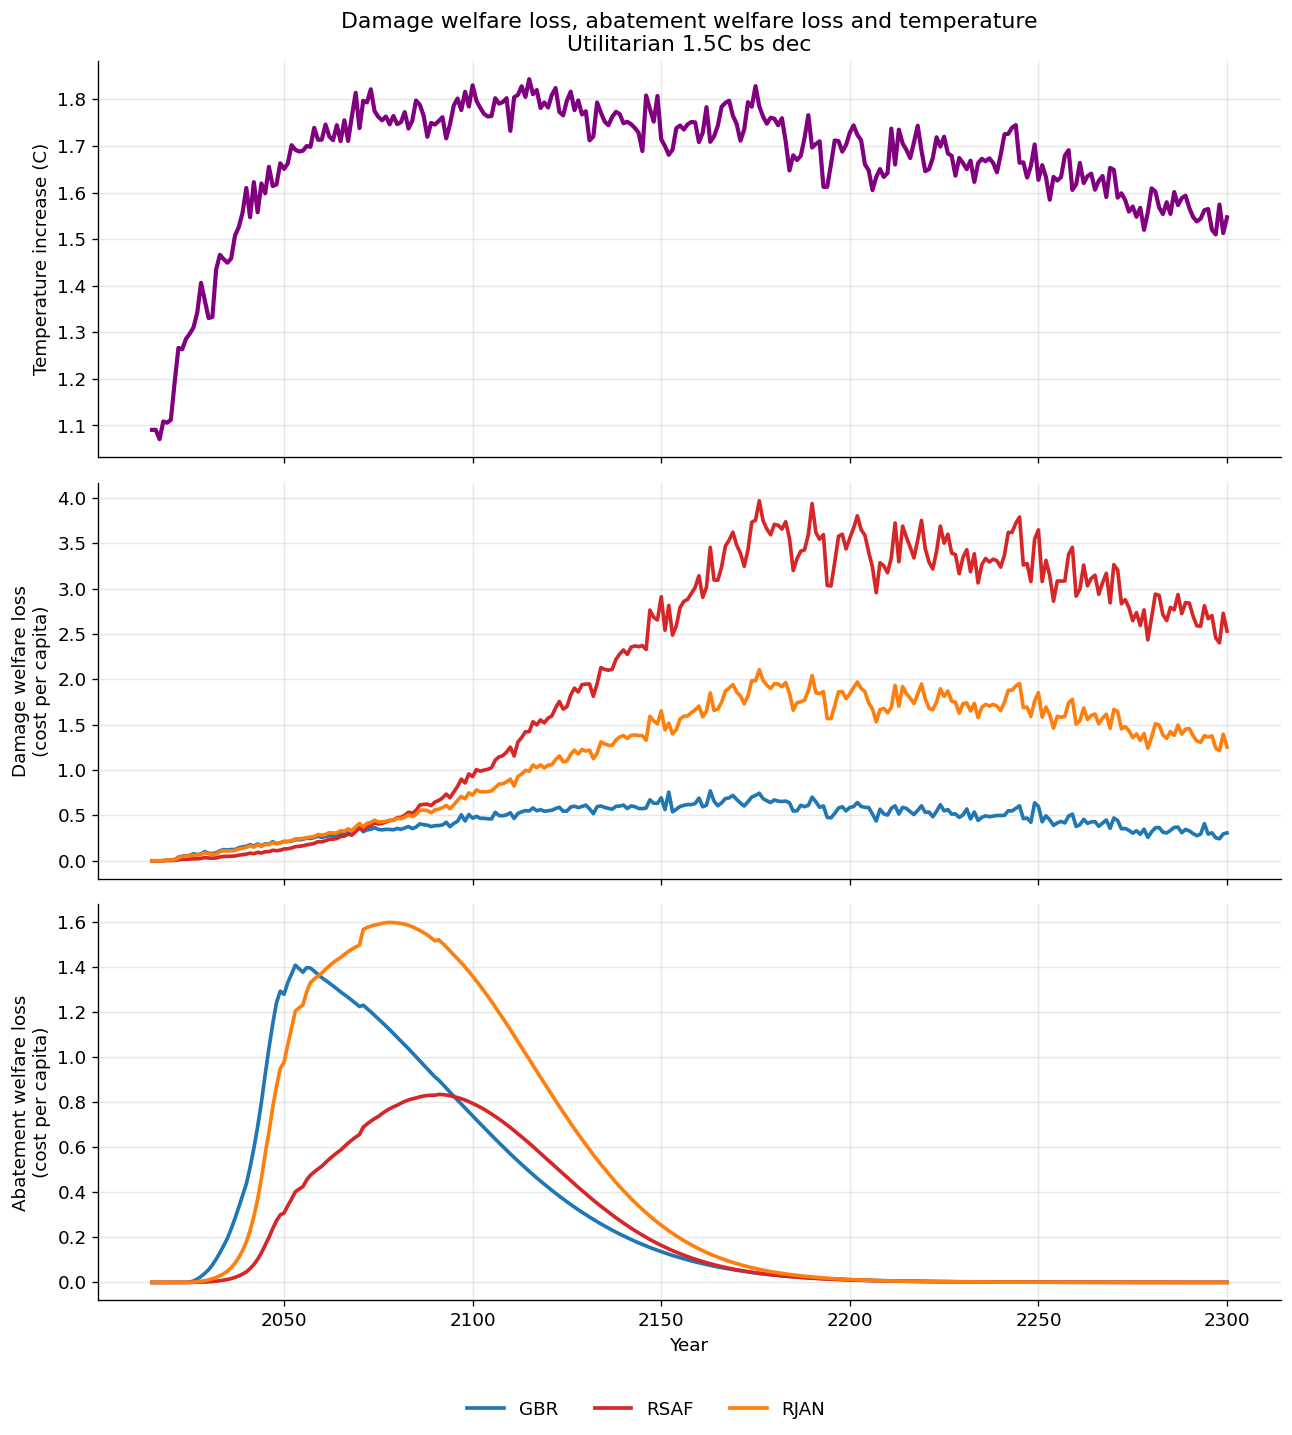

In [ ]:
#Regional damage/abatement welfare loss + temperature, used for the debate
plot_label = "Utilitarian 1.5C bs dec"   
datasets = lowest_threshold_emissions_results[plot_label]["datasets"]

def region_idx(code):
    return [r.lower() for r in REGION_LIST].index(code.lower())

gbr_idx = find_gbr_index()
rsaf_idx = region_idx("rsaf")
rjan_idx = region_idx("rjan57")

def regional_series(datasets, key, idx):
    arr = np.asarray(datasets[key])          
    return np.nanmean(arr[idx, :, :], axis=1)

temp_series = mean_global_temperature(datasets)

gbr_damage = regional_series(datasets, "damage_cost_per_capita", gbr_idx)
rsaf_damage = regional_series(datasets, "damage_cost_per_capita", rsaf_idx)
rjan_damage = regional_series(datasets, "damage_cost_per_capita", rjan_idx)

gbr_abatement = regional_series(datasets, "abatement_cost_per_capita", gbr_idx)
rsaf_abatement = regional_series(datasets, "abatement_cost_per_capita", rsaf_idx)
rjan_abatement = regional_series(datasets, "abatement_cost_per_capita", rjan_idx)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 12), sharex=True, dpi=120)

c_gbr = "#1f77b4"
c_rsaf = "#d62728"
c_rjan = "#ff7f0e"

ax1.plot(years, temp_series, color="purple", linewidth=2.5, label="Global temperature")
ax1.set_ylabel("Temperature increase (C)")
ax1.set_title(f"Damage welfare loss, abatement welfare loss and temperature\n{plot_label}")
ax1.grid(alpha=0.3)

ax2.plot(years, gbr_damage, color=c_gbr, linewidth=2.2, label="GBR")
ax2.plot(years, rsaf_damage, color=c_rsaf, linewidth=2.2, label="RSAF")
ax2.plot(years, rjan_damage, color=c_rjan, linewidth=2.2, label="RJAN")
ax2.set_ylabel("Damage welfare loss\n(cost per capita)")
ax2.grid(alpha=0.3)

ax3.plot(years, gbr_abatement, color=c_gbr, linewidth=2.2, label="GBR")
ax3.plot(years, rsaf_abatement, color=c_rsaf, linewidth=2.2, label="RSAF")
ax3.plot(years, rjan_abatement, color=c_rjan, linewidth=2.2, label="RJAN")
ax3.set_ylabel("Abatement welfare loss\n(cost per capita)")
ax3.set_xlabel("Year")
ax3.grid(alpha=0.3)

handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(os.path.join(PLOTS_DIR, "regional_damage_abatement_temperature_gbr_rsaf_rjan.png"), dpi=150)
plt.show()

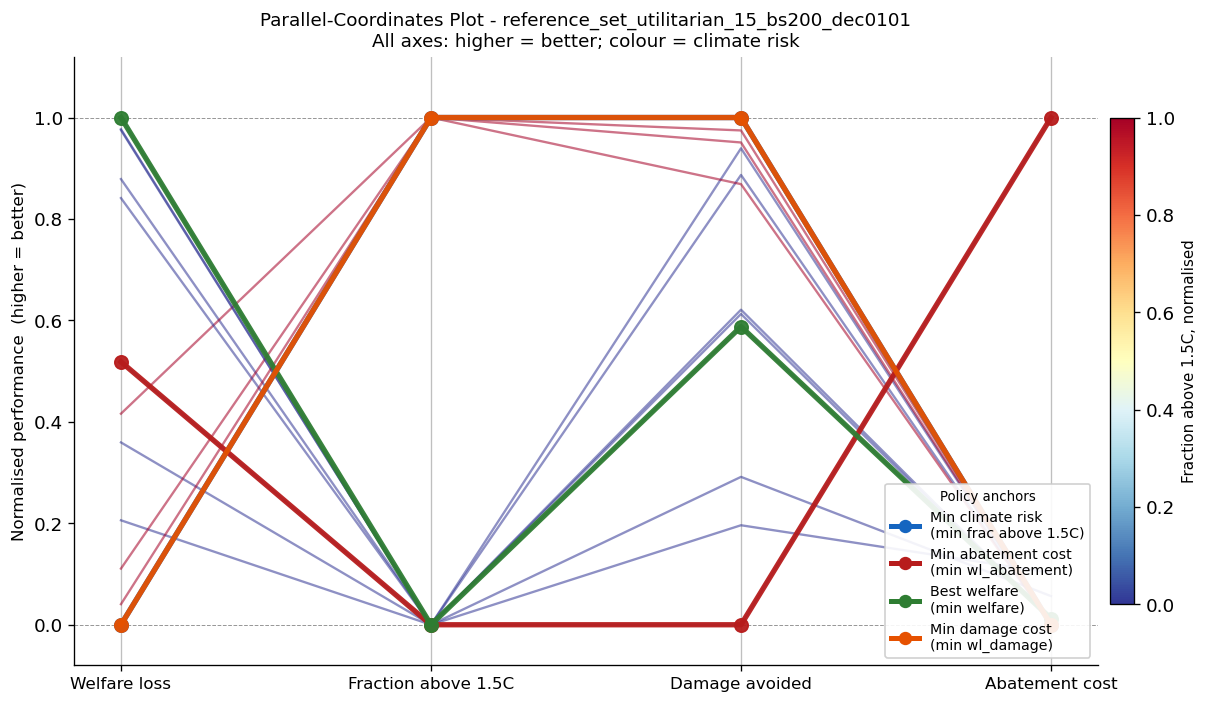

Figure saved: c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\plots\parcoords_reference_set_utilitarian_15_bs200_dec0101.png


In [ ]:
#Parallel-coordinates plot for utilitarian 1.5C bs200 dec0101
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

ref_path = os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_bs200_dec0101.csv")


ref_set = load_reference_set(ref_path)

OBJECTIVE_COLS = [
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

MINIMIZE_COLS = [
    "welfare",
    "fraction_above_threshold",
   
]

MAXIMIZE_COLS = [
     "welfare_loss_abatement",
    "welfare_loss_damage"
]

OBJECTIVE_LABELS = {
    "welfare": "Welfare loss",
    "fraction_above_threshold": "Fraction above 1.5C",
    "welfare_loss_damage": "Damage avoided",
    "welfare_loss_abatement": "Abatement cost",
}

obj = ref_set[OBJECTIVE_COLS].copy().astype(float)


def normalise_for_plot(df_obj):
    """Normalise objectives to [0, 1] with 1 = best."""
    normed = df_obj.copy().astype(float)

    for col in MINIMIZE_COLS:
        lo, hi = normed[col].min(), normed[col].max()
        normed[col] = 1.0 - (normed[col] - lo) / (hi - lo + 1e-15)

    for col in MAXIMIZE_COLS:
        lo, hi = normed[col].min(), normed[col].max()
        normed[col] = (normed[col] - lo) / (hi - lo + 1e-15)

    return normed


obj_norm = normalise_for_plot(obj)

#Identify policy extremes
extremes = {
    "Min climate risk\n(min frac above 1.5C)": obj["fraction_above_threshold"].idxmin(),
    "Min abatement cost\n(min wl_abatement)": obj["welfare_loss_abatement"].idxmax(),
    "Best welfare\n(min welfare)": obj["welfare"].idxmin(),
    "Min damage cost\n(min wl_damage)": obj["welfare_loss_damage"].idxmax(),
}

extreme_colors = ["#1565C0", "#B71C1C", "#2E7D32", "#E65100"]

# Create the plot
fig, ax = plt.subplots(figsize=(11, 6))

x_pos = np.arange(len(OBJECTIVE_COLS))
axis_labels = [OBJECTIVE_LABELS[c] for c in OBJECTIVE_COLS]

frac_vals = obj_norm["fraction_above_threshold"].values
cmap_risk = plt.cm.RdYlBu_r
norm_risk = Normalize(vmin=frac_vals.min(), vmax=frac_vals.max())

for idx, row in obj_norm.iterrows():
    y = row[OBJECTIVE_COLS].values
    color = cmap_risk(norm_risk(row["fraction_above_threshold"]))
    ax.plot(x_pos, y, color=color, lw=1.4, alpha=0.55, zorder=2)

for (label, idx), ec in zip(extremes.items(), extreme_colors):
    y = obj_norm.loc[idx, OBJECTIVE_COLS].values
    ax.plot(
        x_pos,
        y,
        color=ec,
        lw=3.2,
        alpha=0.95,
        zorder=5,
        marker="o",
        markersize=8,
    )

for xi in x_pos:
    ax.axvline(xi, color="0.75", lw=0.8, zorder=1)

ax.set_xticks(x_pos)
ax.set_xticklabels(axis_labels, fontsize=10)
ax.set_ylabel("Normalised performance  (higher = better)", fontsize=10)
ax.set_ylim(-0.08, 1.12)
ax.axhline(0, color="0.6", lw=0.6, linestyle="--")
ax.axhline(1, color="0.6", lw=0.6, linestyle="--")

ax.set_title(
    "Parallel-Coordinates Plot - reference_set_utilitarian_15_bs200_dec0101\n"
    "All axes: higher = better; colour = climate risk",
    fontsize=11,
)

sm = plt.cm.ScalarMappable(cmap=cmap_risk, norm=norm_risk)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01, shrink=0.8)
cbar.set_label("Fraction above 1.5C, normalised", fontsize=9)

legend_handles = [
    Line2D([0], [0], color=ec, lw=3, marker="o", markersize=7, label=lbl)
    for (lbl, _), ec in zip(extremes.items(), extreme_colors)
]

ax.legend(
    handles=legend_handles,
    fontsize=8.5,
    loc="lower right",
    framealpha=0.9,
    title="Policy anchors",
    title_fontsize=8,
)

plt.tight_layout()

plot_path = os.path.join(
    PLOTS_DIR,
    "parcoords_reference_set_utilitarian_15_bs200_dec0101.png",
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved: {plot_path}")